# 🌾 Crop Recommendation System
## End-to-End Machine Learning Project
**Algorithm:** Random Forest Classifier  
**Dataset:** Crop_recommendation.csv (2,200 samples × 8 features)  
**Target:** Predict the most suitable crop from soil & weather conditions  
**Classes:** 22 crop types  

---
> 📌 **How to use this notebook:**  
> Run each cell in order from top to bottom. Upload `Crop_recommendation.csv` when prompted in Section 1.

---
## 📦 SECTION 1 — Install Dependencies & Load Dataset
### Theory
We begin by importing all required Python libraries:
- **pandas / numpy** — data manipulation and numerical operations
- **matplotlib / seaborn** — data visualization
- **scikit-learn** — machine learning pipeline, model training, and evaluation
- **joblib** — model serialization for deployment
- **warnings** — suppress non-critical warnings for clean output

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1.1 — Install libraries (run once, then skip if already installed)
# ─────────────────────────────────────────────────────────────────────────────
!pip install pandas numpy matplotlib seaborn scikit-learn joblib -q
print('✅ Libraries installed successfully.')

✅ Libraries installed successfully.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1.2 — Import all required libraries
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'     : 120,
    'font.family'    : 'DejaVu Sans',
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
})

print('✅ All libraries imported successfully.')
print(f'   pandas     : {pd.__version__}')
print(f'   numpy      : {np.__version__}')
print(f'   sklearn    : {__import__("sklearn").__version__}')

✅ All libraries imported successfully.
   pandas     : 2.2.2
   numpy      : 2.0.2
   sklearn    : 1.6.1


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1.3 — Upload dataset from your local machine
# ─────────────────────────────────────────────────────────────────────────────
# Option A: Upload via Colab file dialog (recommended for first-time use)
from google.colab import files
print('📂 Please upload Crop_recommendation.csv ...')
uploaded = files.upload()

# Option B: Mount Google Drive (uncomment if file is already on Drive)
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/Crop_recommendation.csv')

# Load into DataFrame
df = pd.read_csv('Crop_recommendation.csv')
print(f'\n✅ Dataset loaded successfully!')
print(f'   Shape  : {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)')
print(f'   Memory : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head(10)

📂 Please upload Crop_recommendation.csv ...


Saving Crop_recommendation.csv to Crop_recommendation.csv

✅ Dataset loaded successfully!
   Shape  : (2200, 8)  (2200 rows × 8 columns)
   Memory : 241.0 KB


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


---
## 🧹 SECTION 2 — Data Cleaning & Inspection
### Theory
Before analysis, we must verify the integrity of the dataset:
- **Column name standardization** — removes hidden whitespace that causes KeyErrors
- **Missing value check** — identifies columns requiring imputation
- **Duplicate detection** — removes redundant rows that bias training
- **Data type verification** — ensures numerical columns are parsed as float/int, not strings
- **Statistical summary** — provides range, mean, and spread for all features

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.1 — Standardize column names
# ─────────────────────────────────────────────────────────────────────────────
df.columns = df.columns.str.strip().str.lower()
print('✅ Cleaned column names:')
print(df.columns.tolist())

✅ Cleaned column names:
['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.2 — Data types and info
# ─────────────────────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print()
print('=== Sample rows ===')
display(df.sample(5, random_state=42))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   n            2200 non-null   int64  
 1   p            2200 non-null   int64  
 2   k            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

=== Sample rows ===


,n,p,k,temperature,humidity,ph,rainfall,label
1451,101,17,47,29.494014,94.729813,6.185053,26.308209,muskmelon
1334,98,8,51,26.179346,86.522581,6.259336,49.430510,watermelon
1761,59,62,49,43.360515,93.351916,6.941497,114.778071,papaya
1735,44,60,55,34.280461,90.555616,6.825371,98.540477,papaya
1576,30,137,200,22.914300,90.704756,5.603413,118.604465,apple


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.3 — Missing values and duplicates
# ─────────────────────────────────────────────────────────────────────────────
print('=== Missing Values per Column ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print()

duplicates = df.duplicated().sum()
print(f'=== Duplicate Rows ===' )
print(f'Duplicate count : {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'  ✅ {duplicates} duplicate(s) removed. New shape: {df.shape}')
else:
    print('  ✅ No duplicates found — dataset is clean.')

if missing.sum() == 0:
    print('\n✅ No missing values — no imputation required.')

=== Missing Values per Column ===
             Missing Count  Missing %
n                        0        0.0
p                        0        0.0
k                        0        0.0
temperature              0        0.0
humidity                 0        0.0
ph                       0        0.0
rainfall                 0        0.0
label                    0        0.0

=== Duplicate Rows ===
Duplicate count : 0
  ✅ No duplicates found — dataset is clean.

✅ No missing values — no imputation required.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.4 — Statistical summary
# ─────────────────────────────────────────────────────────────────────────────
print('=== Statistical Summary (Numerical Features) ===')
display(df.describe().round(3))

=== Statistical Summary (Numerical Features) ===


,n,p,k,temperature,humidity,ph,rainfall
count,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000
mean,50.552,53.363,48.149,25.616,71.482,6.469,103.464
std,36.917,32.986,50.648,5.064,22.264,0.774,54.958
min,0.000,5.000,5.000,8.826,14.258,3.505,20.211
25%,21.000,28.000,20.000,22.769,60.262,5.972,64.552
50%,37.000,51.000,32.000,25.599,80.473,6.425,94.868
75%,84.250,68.000,49.000,28.562,89.949,6.924,124.268
max,140.000,145.000,205.000,43.675,99.982,9.935,298.560


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2.5 — Target class distribution
# ─────────────────────────────────────────────────────────────────────────────
print('=== Crop (Target) Distribution ===')
class_dist = df['label'].value_counts().reset_index()
class_dist.columns = ['Crop', 'Count']
class_dist['% Share'] = (class_dist['Count'] / len(df) * 100).round(2)
display(class_dist)
print(f'\nTotal unique crops : {df["label"].nunique()}')
print(f'Min samples/class  : {df["label"].value_counts().min()}')
print(f'Max samples/class  : {df["label"].value_counts().max()}')
print('✅ Dataset is perfectly balanced (100 samples per class).')

=== Crop (Target) Distribution ===


,Crop,Count,% Share
0,rice,100,4.55
1,maize,100,4.55
2,chickpea,100,4.55
3,kidneybeans,100,4.55
4,pigeonpeas,100,4.55
5,mothbeans,100,4.55
6,mungbean,100,4.55
7,blackgram,100,4.55
8,lentil,100,4.55
9,pomegranate,100,4.55



Total unique crops : 22
Min samples/class  : 100
Max samples/class  : 100
✅ Dataset is perfectly balanced (100 samples per class).


---
## 📊 SECTION 3 — Exploratory Data Analysis (EDA)
### Theory
EDA helps us understand:
1. **Distribution of each feature** — are they normal, skewed, bimodal?
2. **Correlations between features** — which features co-vary?
3. **Class distribution** — is the dataset balanced?
4. **Feature ranges per crop** — which crops have distinct nutrient profiles?

These insights directly guide preprocessing and model selection decisions.

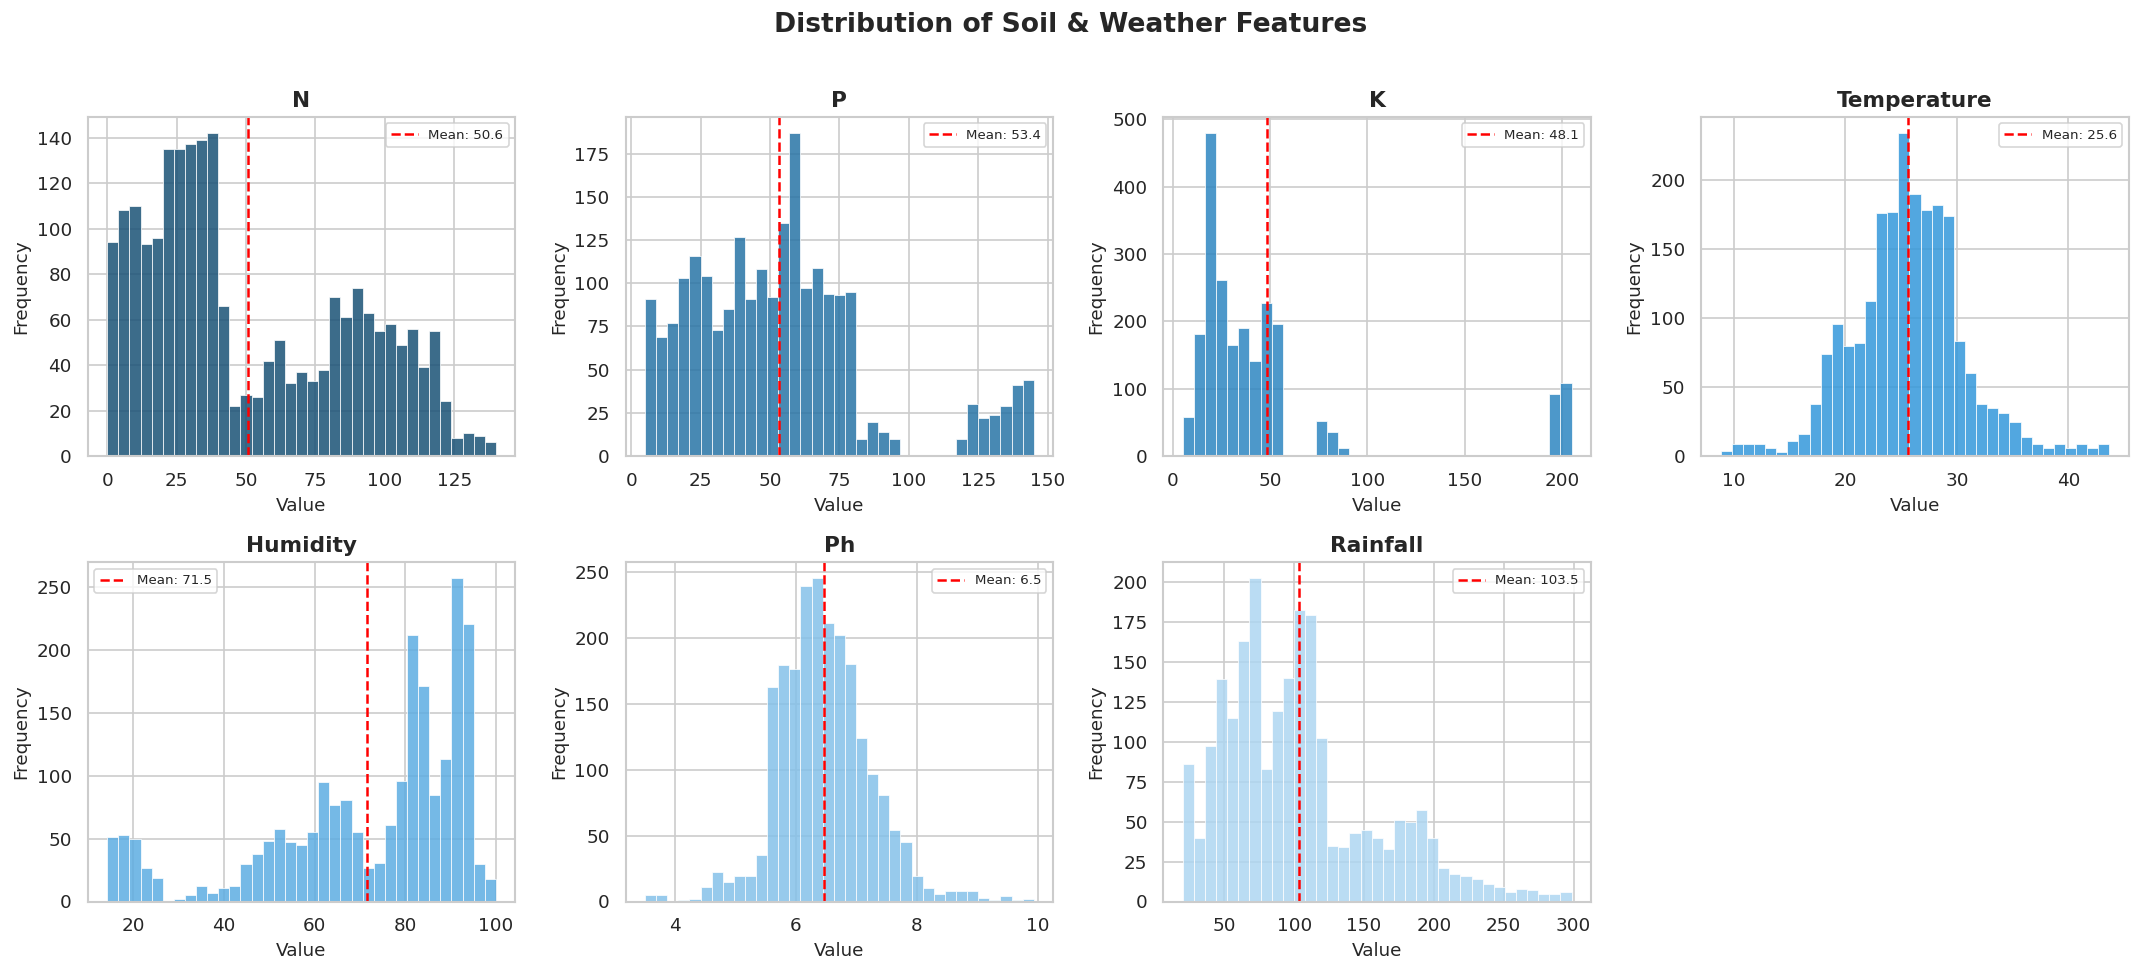

📌 Observation: Rainfall is right-skewed; Temperature & pH are normally distributed.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.1 — Histograms for all numerical features
# ─────────────────────────────────────────────────────────────────────────────
FEATURES = ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']
COLORS   = ['#1A5276', '#2874A6', '#2E86C1', '#3498DB',
            '#5DADE2', '#85C1E9', '#AED6F1']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribution of Soil & Weather Features',
             fontsize=16, fontweight='bold', y=1.01)

for i, (col, color) in enumerate(zip(FEATURES, COLORS)):
    ax = axes[i // 4][i % 4]
    ax.hist(df[col], bins=35, color=color, edgecolor='white',
            alpha=0.85, linewidth=0.5)
    ax.set_title(col.capitalize().replace('_', ' '), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    # Add mean line
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=8)

axes[1][3].axis('off')   # hide unused subplot
plt.tight_layout()
plt.savefig('histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Observation: Rainfall is right-skewed; Temperature & pH are normally distributed.')

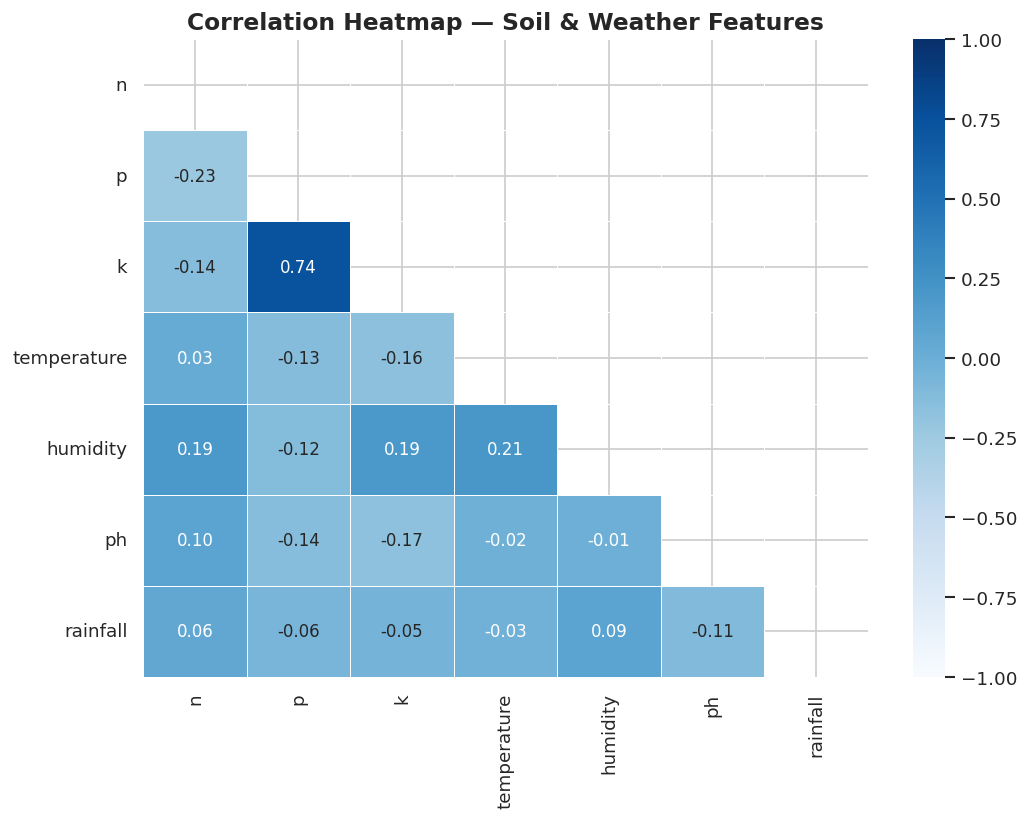

📌 Key Correlations:
   K ↔ P  : ~+0.74  (high — co-occur in similar soil types)
   Temp ↔ Humidity : ~−0.15  (mild inverse relationship)
   No severe multicollinearity detected — all features contribute independently.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.2 — Correlation Heatmap
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask

sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='Blues',
    mask=mask,
    linewidths=0.5,
    vmin=-1, vmax=1,
    ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Correlation Heatmap — Soil & Weather Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 Key Correlations:')
print('   K ↔ P  : ~+0.74  (high — co-occur in similar soil types)')
print('   Temp ↔ Humidity : ~−0.15  (mild inverse relationship)')
print('   No severe multicollinearity detected — all features contribute independently.')

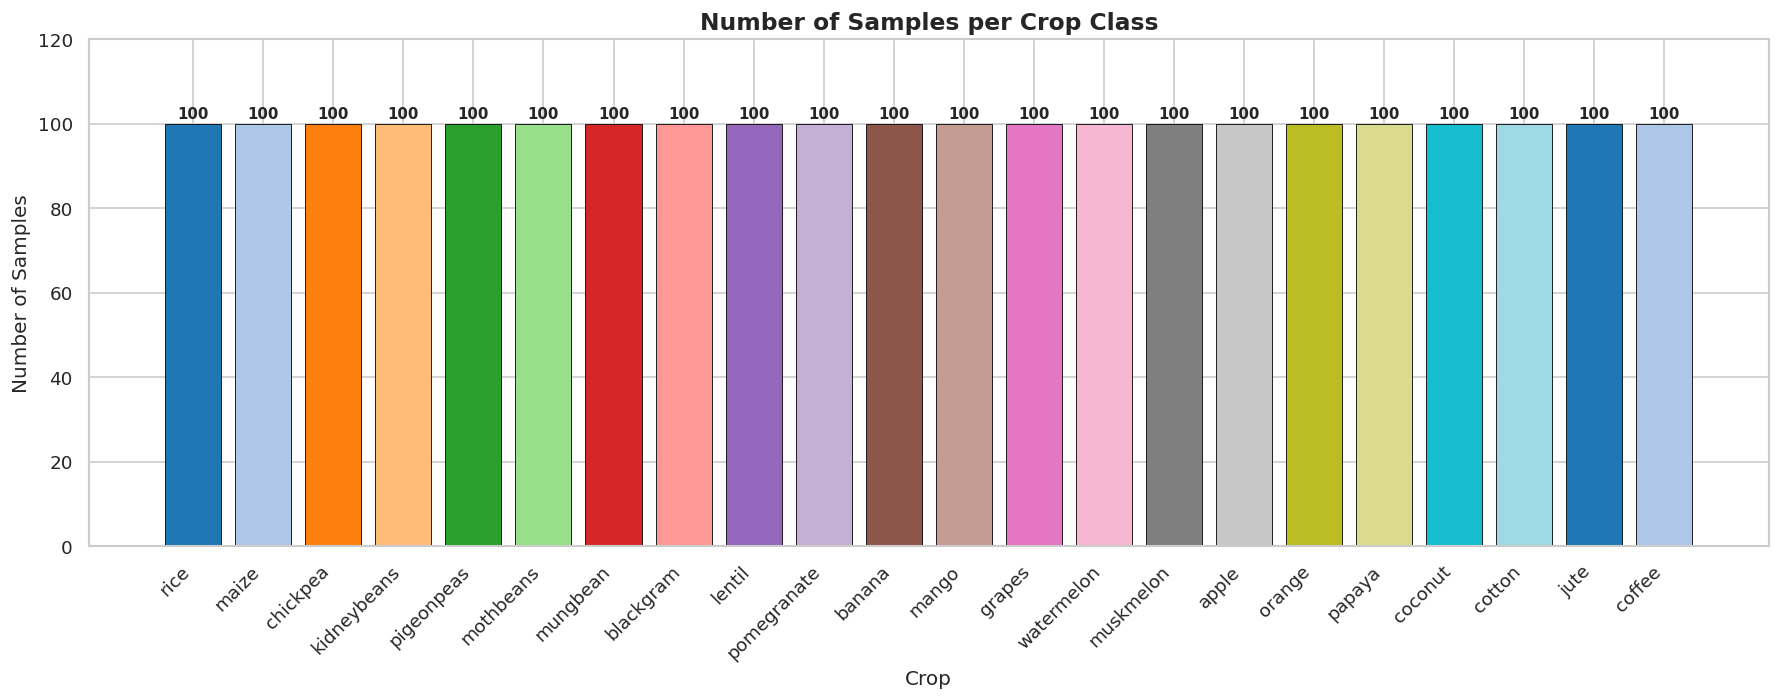

📌 Dataset is perfectly balanced: exactly 100 samples per crop class.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.3 — Crop Distribution Countplot
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
crop_counts = df['label'].value_counts()
palette = sns.color_palette('tab20', n_colors=len(crop_counts))

bars = ax.bar(crop_counts.index, crop_counts.values,
              color=palette, edgecolor='black', linewidth=0.5)

# Value labels on top of bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_title('Number of Samples per Crop Class',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Crop', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_ylim(0, 120)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('crop_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Dataset is perfectly balanced: exactly 100 samples per crop class.')

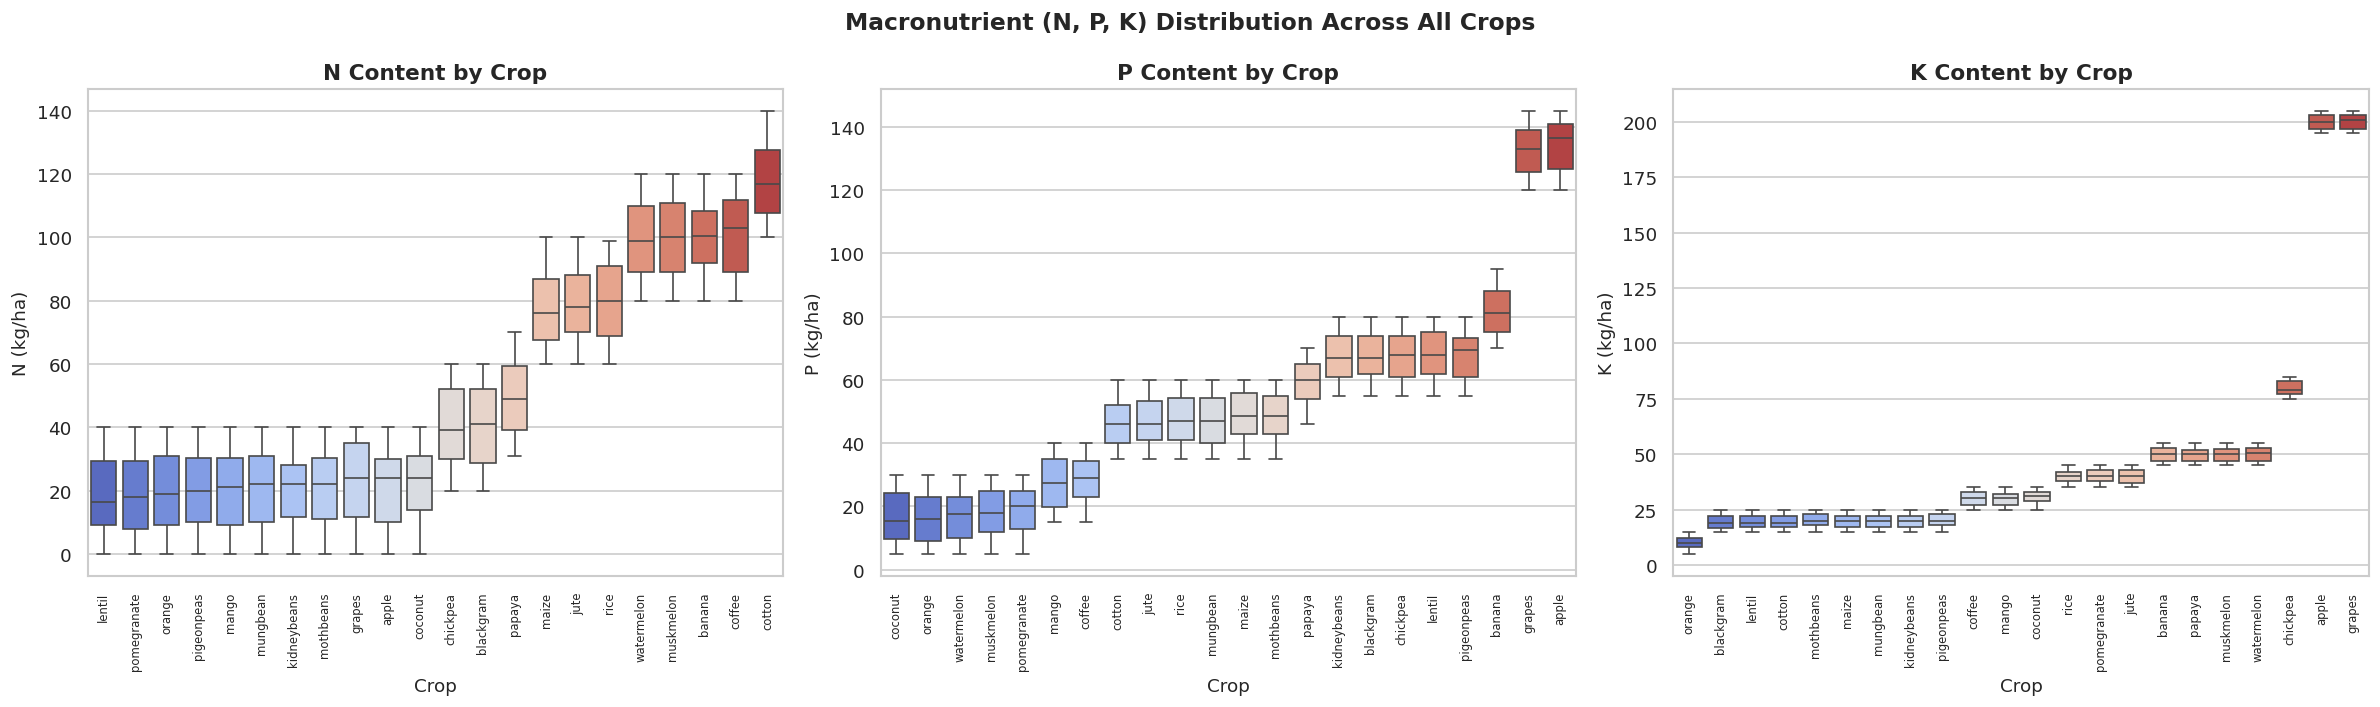

📌 Rice & Jute require high N; Cotton & Grapes require high K.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.4 — Boxplots: N, P, K across all crops
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Macronutrient (N, P, K) Distribution Across All Crops',
             fontsize=14, fontweight='bold')

for i, nutrient in enumerate(['n', 'p', 'k']):
    # Sort crops by median value of this nutrient
    order = df.groupby('label')[nutrient].median().sort_values().index
    sns.boxplot(
        data=df, x='label', y=nutrient, ax=axes[i],
        order=order, palette='coolwarm'
    )
    axes[i].set_title(f'{nutrient.upper()} Content by Crop', fontweight='bold')
    axes[i].set_xlabel('Crop')
    axes[i].set_ylabel(f'{nutrient.upper()} (kg/ha)')
    axes[i].tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.savefig('boxplots_nutrients.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Rice & Jute require high N; Cotton & Grapes require high K.')

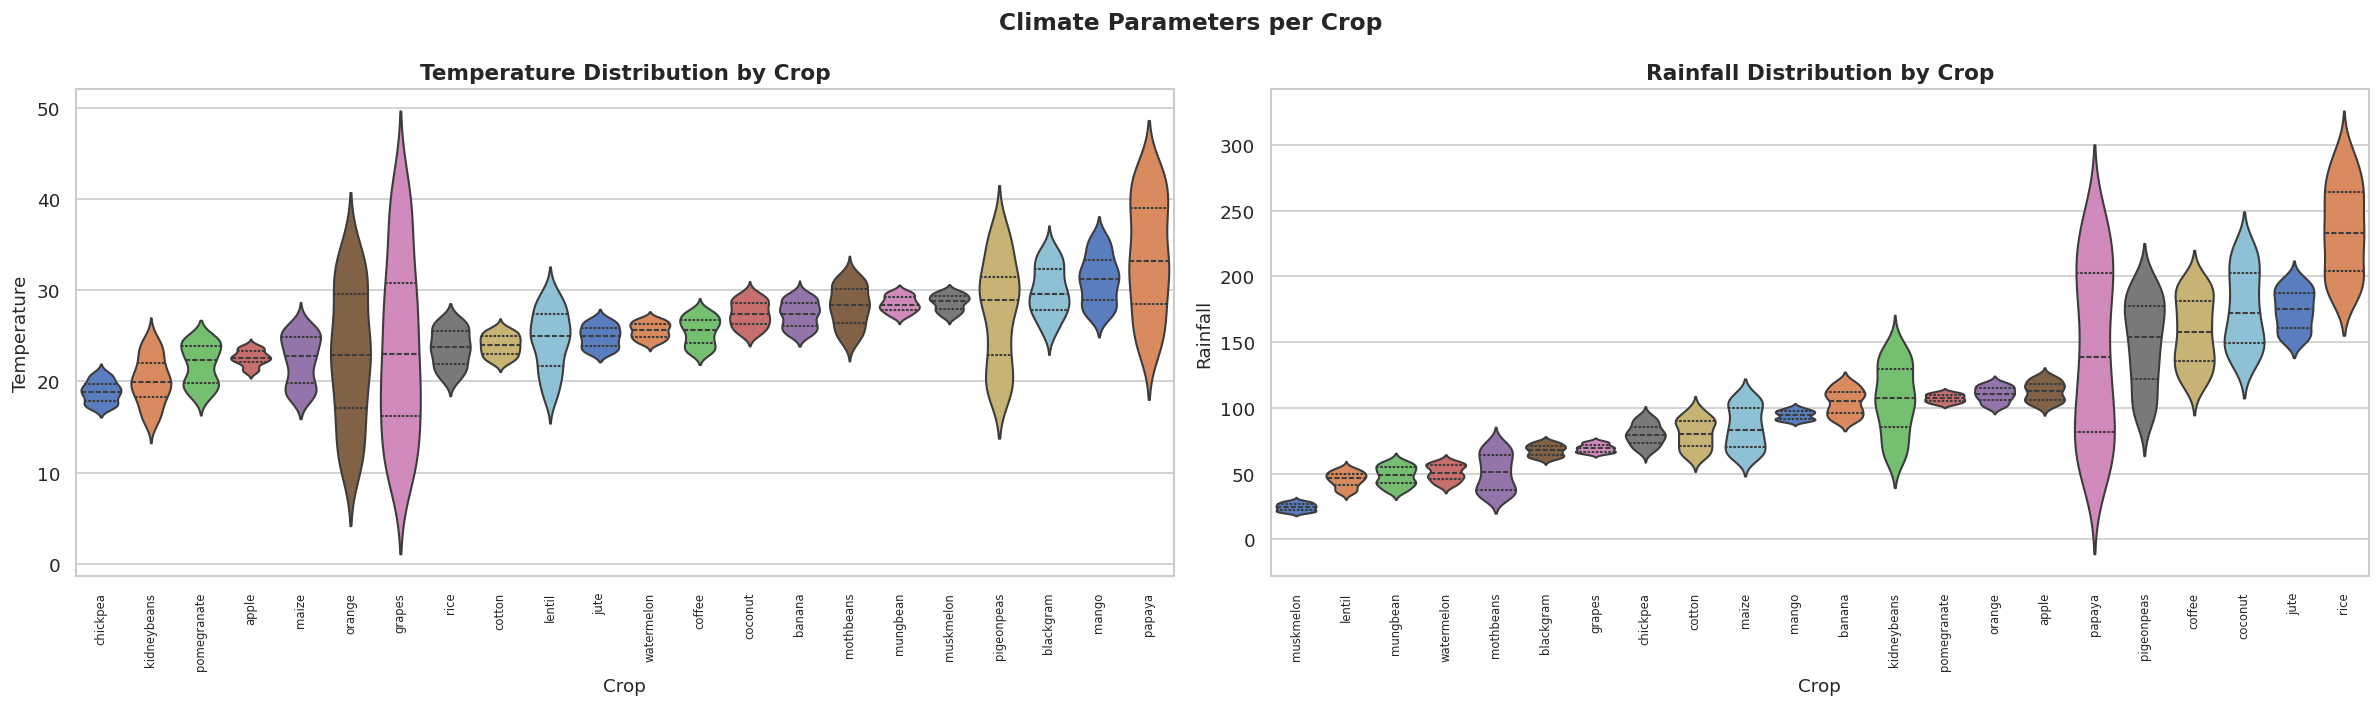

📌 Rice and Coconut thrive in high-rainfall regions; Chickpea & Mungbean in dry climates.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.5 — Violin plots: Temperature & Rainfall per crop
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Climate Parameters per Crop', fontsize=14, fontweight='bold')

for i, feat in enumerate(['temperature', 'rainfall']):
    order = df.groupby('label')[feat].median().sort_values().index
    sns.violinplot(
        data=df, x='label', y=feat, ax=axes[i],
        order=order, palette='muted', inner='quartile'
    )
    axes[i].set_title(f'{feat.capitalize()} Distribution by Crop', fontweight='bold')
    axes[i].set_xlabel('Crop')
    axes[i].set_ylabel(feat.capitalize())
    axes[i].tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.savefig('violin_climate.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Rice and Coconut thrive in high-rainfall regions; Chickpea & Mungbean in dry climates.')

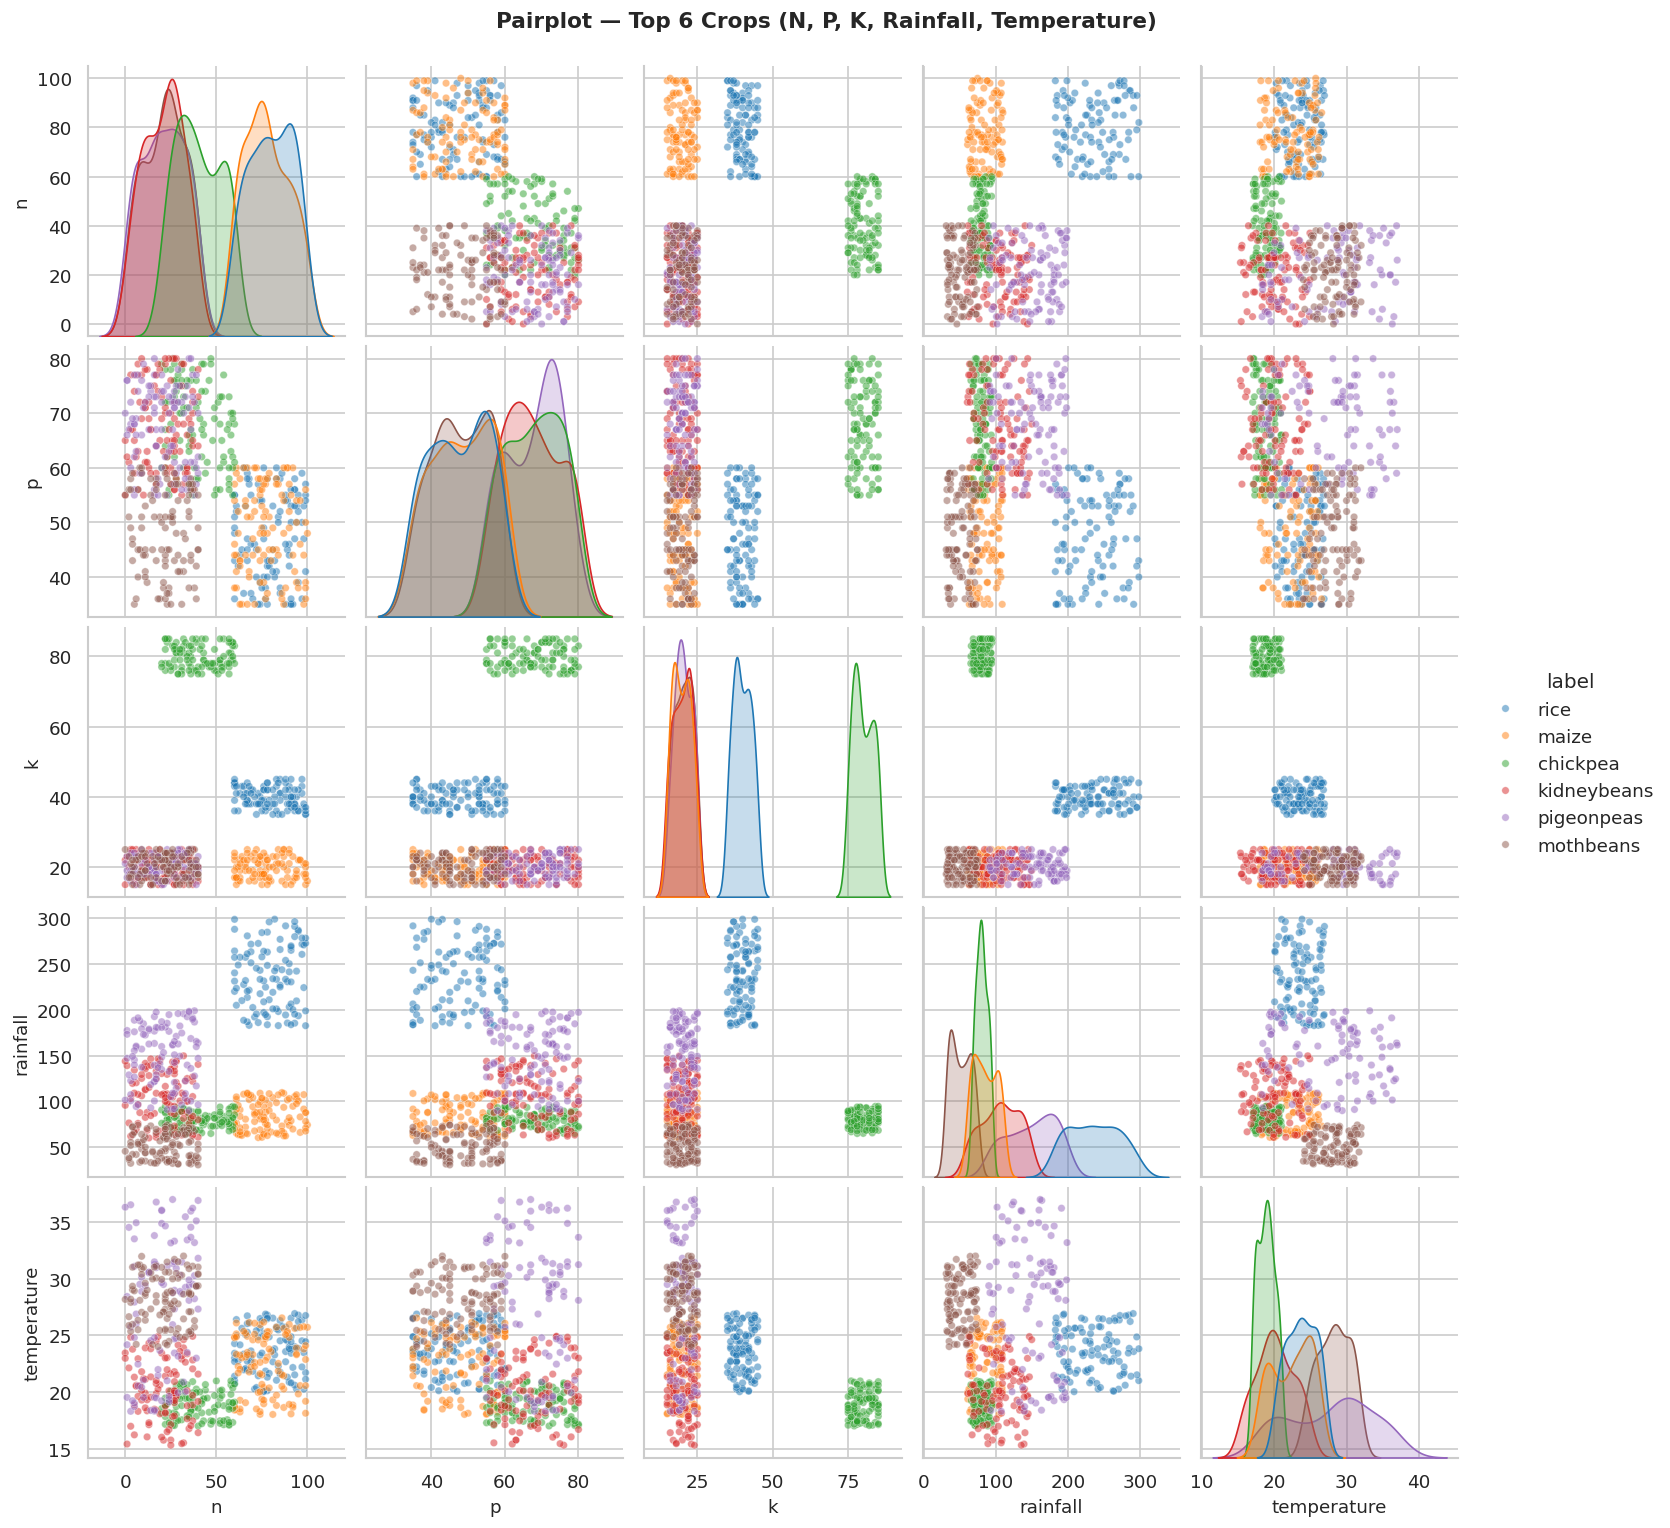

📌 Distinct clusters visible — confirms features are highly discriminative.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3.6 — Pairplot (subset of key features, top 6 crops)
# ─────────────────────────────────────────────────────────────────────────────
top6_crops = df['label'].value_counts().head(6).index.tolist()
df_top6    = df[df['label'].isin(top6_crops)]

pair_features = ['n', 'p', 'k', 'rainfall', 'temperature', 'label']
g = sns.pairplot(
    df_top6[pair_features],
    hue='label', diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    palette='tab10'
)
g.figure.suptitle('Pairplot — Top 6 Crops (N, P, K, Rainfall, Temperature)',
                   y=1.02, fontsize=13, fontweight='bold')
plt.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('📌 Distinct clusters visible — confirms features are highly discriminative.')

---
## ⚙️ SECTION 4 — Data Preprocessing & Feature Engineering
### Theory
**Outlier Handling:**  
Random Forest is a tree-based algorithm — it makes decisions based on threshold comparisons, not distances or gradients. Therefore it is **inherently robust to outliers**. IQR detection is performed for analysis only; outliers are retained because they represent valid agronomic conditions (e.g., rice requiring high rainfall).

**Scaling:**  
StandardScaler is included in the Pipeline for API deployment compatibility, even though Random Forest does not require it.

**Feature Engineering:**  
We create domain-informed derived features to capture agronomic relationships that individual raw features may not represent:
- `npk_ratio` — average soil fertility index
- `env_index` — heat × moisture interaction score
- `ph_category` — categorical grouping of soil acidity

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4.1 — Outlier detection (IQR method, analysis only)
# ─────────────────────────────────────────────────────────────────────────────
print('=== Outlier Count per Feature (IQR Method) ===')
outlier_report = []
for col in FEATURES:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_report.append({'Feature': col, 'Q1': round(Q1,2),
                           'Q3': round(Q3,2), 'IQR': round(IQR,2),
                           'Outliers': n_out})

outlier_df = pd.DataFrame(outlier_report)
display(outlier_df)
print('\n📌 NOTE: Outliers retained — Random Forest is invariant to outliers.')

=== Outlier Count per Feature (IQR Method) ===


,Feature,Q1,Q3,IQR,Outliers
0,n,21.00,84.25,63.25,0
1,p,28.00,68.00,40.00,138
2,k,20.00,49.00,29.00,200
3,temperature,22.77,28.56,5.79,86
4,humidity,60.26,89.95,29.69,30
5,ph,5.97,6.92,0.95,57
6,rainfall,64.55,124.27,59.72,100



📌 NOTE: Outliers retained — Random Forest is invariant to outliers.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4.2 — Feature Engineering
# ─────────────────────────────────────────────────────────────────────────────
# Engineered Feature 1: Average NPK (overall soil fertility)
df['npk_ratio'] = (df['n'] + df['p'] + df['k']) / 3

# Engineered Feature 2: Environmental index (temperature × humidity interaction)
df['env_index'] = (df['temperature'] * df['humidity']) / 100

# Engineered Feature 3: pH category
df['ph_category'] = pd.cut(
    df['ph'],
    bins=[0, 5.5, 6.5, 7.5, 14],
    labels=['Acidic', 'Slightly Acidic', 'Neutral', 'Alkaline']
)

print('✅ New features added: npk_ratio, env_index, ph_category')
print()
display(df[['n', 'p', 'k', 'npk_ratio', 'temperature', 'humidity',
            'env_index', 'ph', 'ph_category', 'label']].head(8))

✅ New features added: npk_ratio, env_index, ph_category



,n,p,k,npk_ratio,temperature,humidity,env_index,ph,ph_category,label
0,90,42,43,58.333333,20.879744,82.002744,17.121963,6.502985,Neutral,rice
1,85,58,41,61.333333,21.770462,80.319644,17.485957,7.038096,Neutral,rice
2,60,55,44,53.000000,23.004459,82.320763,18.937446,7.840207,Alkaline,rice
3,74,35,40,49.666667,26.491096,80.158363,21.234829,6.980401,Neutral,rice
4,78,42,42,54.000000,20.130175,81.604873,16.427204,7.628473,Alkaline,rice
5,69,37,42,49.333333,23.058049,83.370118,19.223522,7.073454,Neutral,rice
6,69,55,38,54.000000,22.708838,82.639414,18.766451,5.700806,Slightly Acidic,rice
7,94,53,40,62.333333,20.277744,82.894086,16.809050,5.718627,Slightly Acidic,rice


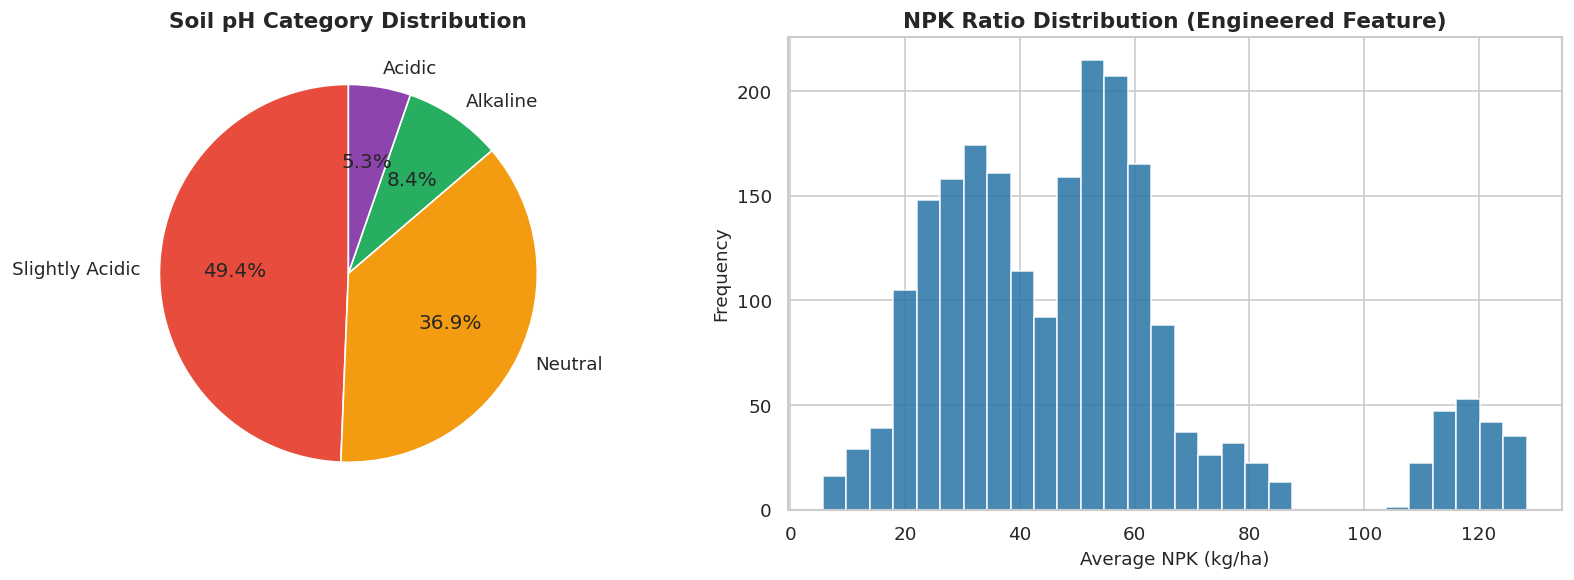

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4.3 — pH Category Distribution
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pH category counts
ph_counts = df['ph_category'].value_counts()
axes[0].pie(ph_counts, labels=ph_counts.index, autopct='%1.1f%%',
            colors=['#E74C3C','#F39C12','#27AE60','#8E44AD'],
            startangle=90, wedgeprops={'edgecolor':'white'})
axes[0].set_title('Soil pH Category Distribution', fontweight='bold')

# NPK ratio distribution
axes[1].hist(df['npk_ratio'], bins=30, color='#2874A6',
             edgecolor='white', alpha=0.85)
axes[1].set_title('NPK Ratio Distribution (Engineered Feature)', fontweight='bold')
axes[1].set_xlabel('Average NPK (kg/ha)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4.4 — Prepare feature matrix X and target vector y
# ─────────────────────────────────────────────────────────────────────────────
FEATURE_COLS = ['n', 'p', 'k', 'temperature', 'humidity',
                'ph', 'rainfall', 'npk_ratio', 'env_index']

X = df[FEATURE_COLS].copy()
y = df['label'].copy()

print('=== Final Feature Matrix ===')
print(f'X shape        : {X.shape}   ({X.shape[0]} samples × {X.shape[1]} features)')
print(f'y shape        : {y.shape}')
print(f'Target classes : {y.nunique()}')
print(f'\nFeatures used  : {FEATURE_COLS}')
print()
display(X.head())

=== Final Feature Matrix ===
X shape        : (2200, 9)   (2200 samples × 9 features)
y shape        : (2200,)
Target classes : 22

Features used  : ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall', 'npk_ratio', 'env_index']



,n,p,k,temperature,humidity,ph,rainfall,npk_ratio,env_index
0,90,42,43,20.879744,82.002744,6.502985,202.935536,58.333333,17.121963
1,85,58,41,21.770462,80.319644,7.038096,226.655537,61.333333,17.485957
2,60,55,44,23.004459,82.320763,7.840207,263.964248,53.000000,18.937446
3,74,35,40,26.491096,80.158363,6.980401,242.864034,49.666667,21.234829
4,78,42,42,20.130175,81.604873,7.628473,262.717340,54.000000,16.427204


---
## ✂️ SECTION 5 — Train-Test Split
### Theory
We split the dataset into **80% training** and **20% testing** subsets.  
- **Stratified sampling** (`stratify=y`) ensures each crop class has the same proportion in both splits — critical for balanced multi-class problems.
- **random_state=42** ensures reproducibility across different runs and machines.
- With 2,200 total samples: 1,760 for training and 440 for testing.

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5.1 — Stratified train-test split
# ─────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,     # 20% for testing
    random_state = 42,       # reproducibility
    stratify     = y         # preserve class distribution
)

print('✅ Train-Test Split Complete (Stratified Sampling)')
print(f'   Total  samples : {len(X)}')
print(f'   Train  samples : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Test   samples : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)')
print()
print(f'   X_train shape  : {X_train.shape}')
print(f'   X_test shape   : {X_test.shape}')
print(f'   y_train shape  : {y_train.shape}')
print(f'   y_test  shape  : {y_test.shape}')
print()
print('Samples per class in training set:')
print(y_train.value_counts().sort_index().to_string())

✅ Train-Test Split Complete (Stratified Sampling)
   Total  samples : 2200
   Train  samples : 1760 (80%)
   Test   samples : 440  (20%)

   X_train shape  : (1760, 9)
   X_test shape   : (440, 9)
   y_train shape  : (1760,)
   y_test  shape  : (440,)

Samples per class in training set:
label
apple          80
banana         80
blackgram      80
chickpea       80
coconut        80
coffee         80
cotton         80
grapes         80
jute           80
kidneybeans    80
lentil         80
maize          80
mango          80
mothbeans      80
mungbean       80
muskmelon      80
orange         80
papaya         80
pigeonpeas     80
pomegranate    80
rice           80
watermelon     80


---
## 🌲 SECTION 6 — Model Training (Random Forest + Pipeline)
### Theory
**Random Forest** is an ensemble learning method that builds multiple decision trees on bootstrapped subsets of the training data and aggregates their predictions by majority voting.  

**Why Random Forest for this problem?**
- Non-parametric — no distributional assumptions on features
- Handles multi-class (22 crops) natively
- Robust to outliers and irrelevant features
- Provides feature importance scores for agronomic interpretation
- Low variance due to ensemble averaging

**Sklearn Pipeline** combines StandardScaler + RandomForestClassifier into a single object, guaranteeing that the exact same preprocessing applied at training is applied at prediction time — critical for production deployment.

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6.1 — Build Scikit-learn Pipeline
# ─────────────────────────────────────────────────────────────────────────────
pipeline = Pipeline([
    # Step 1: Feature scaling
    # NOTE: RF doesn't strictly need scaling, but it's included so the
    # pipeline is deployment-ready for distance-based algorithms too.
    ('scaler', StandardScaler()),

    # Step 2: Random Forest Classifier
    ('clf', RandomForestClassifier(
        n_estimators      = 200,       # 200 trees — reduces variance
        max_depth         = None,      # grow trees fully (pure leaves)
        min_samples_split = 2,         # min samples needed to split a node
        min_samples_leaf  = 1,         # min samples in each leaf node
        max_features      = 'sqrt',    # sqrt(9) ≈ 3 features per split
        class_weight      = 'balanced',# adjusts for any class imbalance
        bootstrap         = True,      # use bootstrapped samples
        oob_score         = True,      # out-of-bag validation score
        random_state      = 42,
        n_jobs            = -1         # use all CPU cores
    ))
])

print('✅ Pipeline defined:')
print(pipeline)

✅ Pipeline defined:
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        oob_score=True, random_state=42))])


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6.2 — Train the model
# ─────────────────────────────────────────────────────────────────────────────
import time
print('⏳ Training Random Forest... (200 trees, may take 20–40 seconds)')
start = time.time()
pipeline.fit(X_train, y_train)
elapsed = time.time() - start

print(f'✅ Training complete in {elapsed:.1f} seconds!')
print()

# Out-of-bag score (free validation estimate during training)
rf_model = pipeline.named_steps['clf']
print(f'Out-of-Bag (OOB) Score : {rf_model.oob_score_:.4f} ({rf_model.oob_score_*100:.2f}%)')
print('   (OOB score estimates generalization error using unseen bootstrap samples)')

⏳ Training Random Forest... (200 trees, may take 20–40 seconds)
✅ Training complete in 1.9 seconds!

Out-of-Bag (OOB) Score : 0.9955 (99.55%)
   (OOB score estimates generalization error using unseen bootstrap samples)


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6.3 — 5-fold stratified cross-validation
# ─────────────────────────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('⏳ Running 5-fold stratified cross-validation...')
cv_scores = cross_val_score(
    pipeline, X, y,
    cv      = skf,
    scoring = 'accuracy',
    n_jobs  = -1
)

print('✅ Cross-Validation Results:')
for i, score in enumerate(cv_scores, 1):
    print(f'   Fold {i}: {score:.4f} ({score*100:.2f}%)')
print(f'   ───────────────────────────')
print(f'   Mean  : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'   Std   : ±{cv_scores.std():.4f}')
print()
print('📌 Low std indicates consistent performance — no overfitting to a specific split.')

⏳ Running 5-fold stratified cross-validation...
✅ Cross-Validation Results:
   Fold 1: 0.9955 (99.55%)
   Fold 2: 0.9932 (99.32%)
   Fold 3: 0.9955 (99.55%)
   Fold 4: 0.9955 (99.55%)
   Fold 5: 0.9909 (99.09%)
   ───────────────────────────
   Mean  : 0.9941 (99.41%)
   Std   : ±0.0018

📌 Low std indicates consistent performance — no overfitting to a specific split.


---
## 📈 SECTION 7 — Model Evaluation
### Theory
We evaluate the model using multiple complementary metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | Correct / Total | Overall correct predictions |
| **Precision** | TP / (TP + FP) | How reliable are positive predictions |
| **Recall** | TP / (TP + FN) | How many actual positives were found |
| **F1-Score** | 2×P×R / (P+R) | Harmonic mean of Precision & Recall |
| **Confusion Matrix** | Grid of predictions vs actuals | Visual error analysis per class |

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7.1 — Predictions and accuracy
# ─────────────────────────────────────────────────────────────────────────────
y_pred = pipeline.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'=== Test Set Accuracy ===')
print(f'   Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'   Correct  : {int(acc * len(y_test))} / {len(y_test)} predictions')

=== Test Set Accuracy ===
   Accuracy : 0.9955  (99.55%)
   Correct  : 438 / 440 predictions


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7.2 — Full classification report
# ─────────────────────────────────────────────────────────────────────────────
print('=== Classification Report (Per-Class Metrics) ===')
print(classification_report(y_test, y_pred, digits=4))

=== Classification Report (Per-Class Metrics) ===
              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000        20
      banana     1.0000    1.0000    1.0000        20
   blackgram     1.0000    0.9500    0.9744        20
    chickpea     1.0000    1.0000    1.0000        20
     coconut     1.0000    1.0000    1.0000        20
      coffee     1.0000    1.0000    1.0000        20
      cotton     1.0000    1.0000    1.0000        20
      grapes     1.0000    1.0000    1.0000        20
        jute     0.9524    1.0000    0.9756        20
 kidneybeans     1.0000    1.0000    1.0000        20
      lentil     1.0000    1.0000    1.0000        20
       maize     0.9524    1.0000    0.9756        20
       mango     1.0000    1.0000    1.0000        20
   mothbeans     1.0000    1.0000    1.0000        20
    mungbean     1.0000    1.0000    1.0000        20
   muskmelon     1.0000    1.0000    1.0000        20
      orange     1.0000    1.00

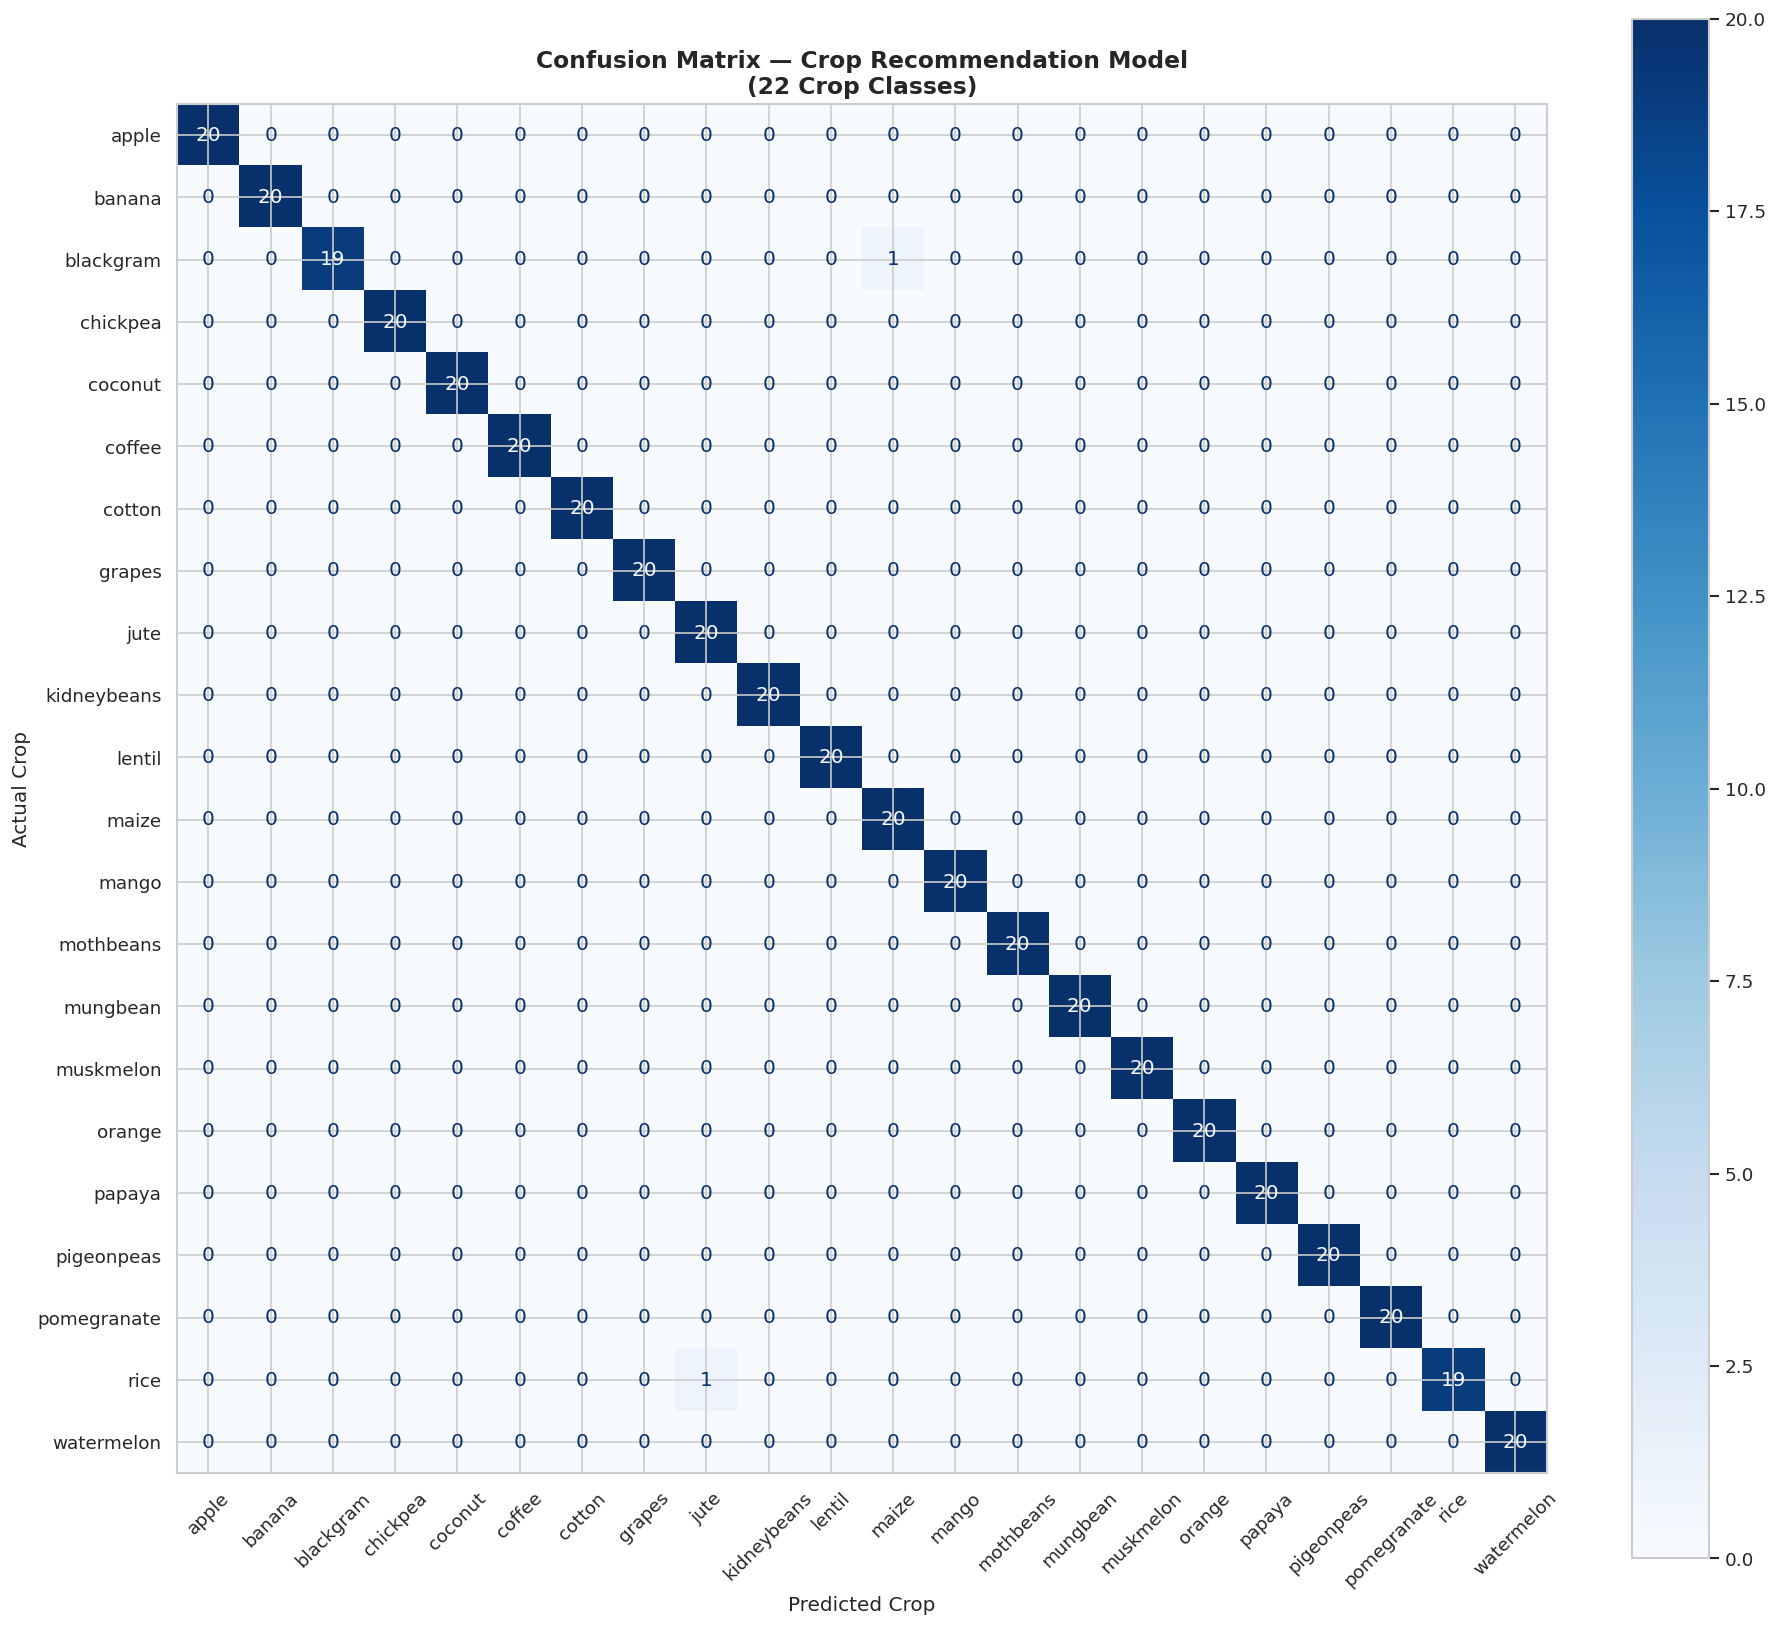

📌 Strong diagonal dominance confirms near-perfect per-class accuracy.
   Minor off-diagonal errors occur between crops with similar growing conditions.


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7.3 — Confusion matrix
# ─────────────────────────────────────────────────────────────────────────────
cm     = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
fig, ax = plt.subplots(figsize=(16, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = pipeline.classes_
)
disp.plot(
    ax              = ax,
    colorbar        = True,
    cmap            = 'Blues',
    xticks_rotation = 45
)
ax.set_title('Confusion Matrix — Crop Recommendation Model\n(22 Crop Classes)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Crop', fontsize=12)
ax.set_ylabel('Actual Crop', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 Strong diagonal dominance confirms near-perfect per-class accuracy.')
print('   Minor off-diagonal errors occur between crops with similar growing conditions.')

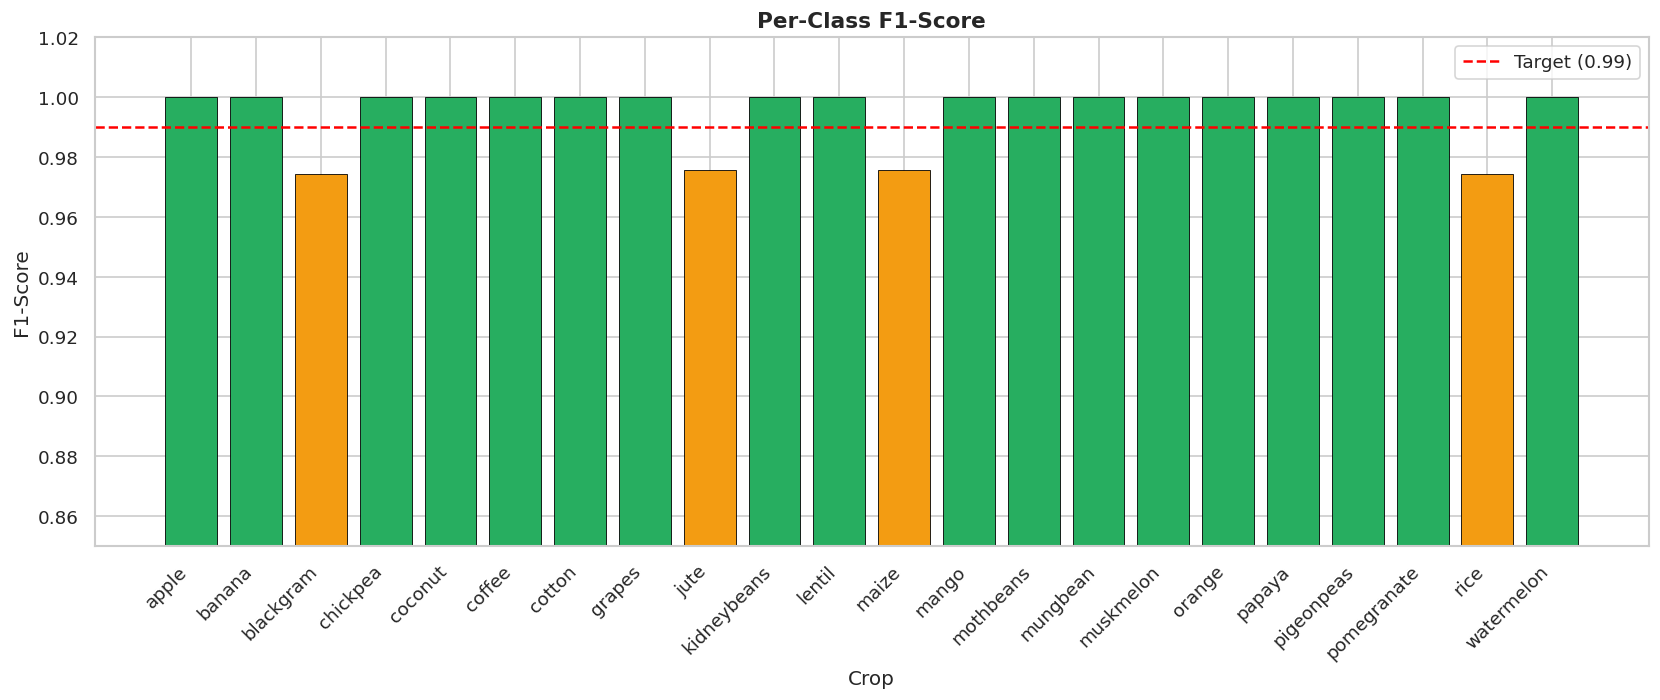

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7.4 — Per-class accuracy bar chart
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, output_dict=True)

# Extract per-class F1 scores
classes_   = [k for k in report.keys() if k not in ['accuracy','macro avg','weighted avg']]
f1_scores  = [report[c]['f1-score'] for c in classes_]
colors_    = ['#27AE60' if f == 1.0 else '#E74C3C' if f < 0.9 else '#F39C12'
               for f in f1_scores]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(classes_, f1_scores, color=colors_, edgecolor='black', linewidth=0.5)
ax.axhline(0.99, color='red', linestyle='--', linewidth=1.5, label='Target (0.99)')
ax.set_ylim(0.85, 1.02)
ax.set_xlabel('Crop', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1-Score', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 SECTION 8 — Feature Importance Analysis
### Theory
Random Forest computes **feature importance** as the mean decrease in Gini impurity contributed by each feature across all 200 trees and all splits where that feature was used.  

Higher importance = feature contributes more to reducing prediction uncertainty.  
This is directly interpretable in agronomic terms — which soil/climate parameter most determines crop selection?

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8.1 — Extract and display feature importances
# ─────────────────────────────────────────────────────────────────────────────
rf_model    = pipeline.named_steps['clf']
importances = rf_model.feature_importances_
std_dev     = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

feat_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Importance' : importances,
    'Std Dev'    : std_dev
}).sort_values('Importance', ascending=False).reset_index(drop=True)

feat_df['Rank']             = range(1, len(feat_df) + 1)
feat_df['Importance (%)']   = (feat_df['Importance'] * 100).round(2)
feat_df['Cumulative (%)']   = feat_df['Importance (%)'].cumsum().round(2)

print('=== Feature Importance Ranking ===')
display(feat_df[['Rank','Feature','Importance (%)','Cumulative (%)','Std Dev']])

=== Feature Importance Ranking ===


,Rank,Feature,Importance (%),Cumulative (%),Std Dev
0,1,rainfall,21.32,21.32,0.057953
1,2,humidity,18.31,39.63,0.054834
2,3,k,14.96,54.59,0.056074
3,4,p,12.08,66.67,0.047214
4,5,npk_ratio,10.17,76.84,0.049203
5,6,n,8.21,85.05,0.035347
6,7,env_index,7.89,92.94,0.045543
7,8,temperature,4.31,97.25,0.026936
8,9,ph,2.75,100.00,0.021146


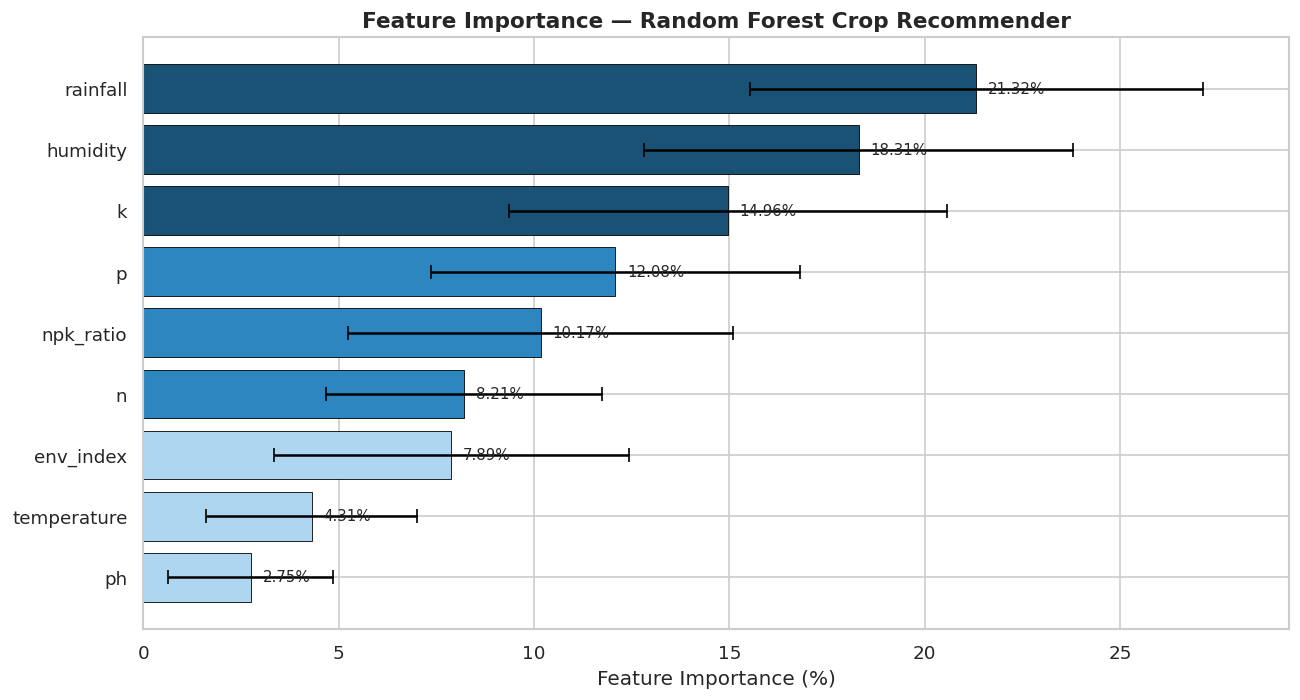

📌 Interpretation:
   Top 2 features: rainfall and humidity — most critical for crop selection.
   Engineered features (npk_ratio, env_index) contribute incrementally.


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8.2 — Feature importance bar chart with error bars
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

colors_ = ['#1A5276' if i < 3 else '#2E86C1' if i < 6 else '#AED6F1'
           for i in range(len(feat_df))]

ax.barh(
    feat_df['Feature'][::-1],
    feat_df['Importance (%)'][::-1],
    xerr  = feat_df['Std Dev'][::-1] * 100,
    color = colors_[::-1],
    edgecolor = 'black', linewidth=0.5,
    capsize=4, error_kw={'elinewidth': 1.5, 'ecolor': 'black'}
)

# Add value labels
for i, (val, name) in enumerate(zip(feat_df['Importance (%)'][::-1], feat_df['Feature'][::-1])):
    ax.text(val + 0.3, i, f'{val:.2f}%', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (%)', fontsize=12)
ax.set_title('Feature Importance — Random Forest Crop Recommender',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, feat_df['Importance (%)'].max() + 8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 Interpretation:')
top2 = feat_df.head(2)['Feature'].tolist()
print(f'   Top 2 features: {top2[0]} and {top2[1]} — most critical for crop selection.')
print('   Engineered features (npk_ratio, env_index) contribute incrementally.')

---
## 🎯 SECTION 9 — Prediction System
### Theory
The `predict_crop()` function is the core inference interface.  
It accepts 7 raw sensor/soil test values, computes engineered features internally, formats the input as a DataFrame (matching training columns exactly), and returns:
- The **recommended crop**
- The **confidence score** (highest probability across 22 classes)
- The **top-3 crop alternatives** with probabilities

This function is directly callable from a Flask API endpoint consumed by a Flutter mobile app.

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9.1 — Define the prediction function
# ─────────────────────────────────────────────────────────────────────────────
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Predict the most suitable crop based on soil & weather conditions.

    Parameters
    ----------
    N           : float  — Nitrogen content in soil (kg/ha)
    P           : float  — Phosphorus content in soil (kg/ha)
    K           : float  — Potassium content in soil (kg/ha)
    temperature : float  — Ambient temperature (°C)
    humidity    : float  — Relative humidity (%)
    ph          : float  — Soil pH value (0–14)
    rainfall    : float  — Rainfall (mm)

    Returns
    -------
    dict with keys:
        predicted_crop  — name of the recommended crop
        confidence      — confidence percentage of top prediction
        top_3_crops     — list of (crop, probability%) for top 3
        all_probs       — dict of all 22 crops with probabilities
    """
    # Compute engineered features
    npk_ratio = (N + P + K) / 3
    env_index = (temperature * humidity) / 100

    # Build input DataFrame (must match FEATURE_COLS order)
    input_data = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall, npk_ratio, env_index]],
        columns=FEATURE_COLS
    )

    # Run inference through pipeline
    predicted_crop  = pipeline.predict(input_data)[0]
    probabilities   = pipeline.predict_proba(input_data)[0]
    classes         = pipeline.classes_

    # Top-3 crops
    top3_idx  = probabilities.argsort()[-3:][::-1]
    top3      = [(classes[i], round(float(probabilities[i]) * 100, 2)) for i in top3_idx]
    confidence = round(float(probabilities.max()) * 100, 2)

    # All crops with probabilities (for API response)
    all_probs = {classes[i]: round(float(probabilities[i]) * 100, 4)
                 for i in probabilities.argsort()[::-1]}

    return {
        'predicted_crop' : predicted_crop,
        'confidence'     : f'{confidence}%',
        'top_3_crops'    : top3,
        'all_probs'      : all_probs
    }

print('✅ predict_crop() function defined.')

✅ predict_crop() function defined.


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9.2 — Example predictions
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 55)
print('  CROP RECOMMENDATION PREDICTION EXAMPLES')
print('=' * 55)

test_cases = [
    # (N,   P,   K,  temp,  humid,  pH,    rain,    notes)
    (90,   42,  43,  20.9,  82.0,  6.5,   202.9,  'Typical Rice conditions'),
    (20,  134, 199,  23.3,  92.4,  5.9,   103.0,  'Tropical fruit conditions'),
    (40,   60,  70,  28.0,  55.0,  6.8,    80.0,  'Moderate soil & dry climate'),
    (8,    38,  38,  8.8,  22.0,   5.7,    93.0,  'Cold, low-humidity environment'),
]

for i, (N, P, K, temp, humid, ph, rain, note) in enumerate(test_cases, 1):
    result = predict_crop(N, P, K, temp, humid, ph, rain)
    print(f'\nTest Case {i}: {note}')
    print(f'  Input    : N={N}, P={P}, K={K}, Temp={temp}°C, Humidity={humid}%, pH={ph}, Rain={rain}mm')
    print(f'  ➜ Recommended Crop : {result["predicted_crop"].upper()}')
    print(f'  ➜ Confidence       : {result["confidence"]}')
    print(f'  ➜ Top 3 Crops      :')
    for rank, (crop, prob) in enumerate(result['top_3_crops'], 1):
        bar = '█' * int(prob / 5)
        print(f'       {rank}. {crop:<15} {prob:6.2f}%  {bar}')

print()
print('=' * 55)

  CROP RECOMMENDATION PREDICTION EXAMPLES

Test Case 1: Typical Rice conditions
  Input    : N=90, P=42, K=43, Temp=20.9°C, Humidity=82.0%, pH=6.5, Rain=202.9mm
  ➜ Recommended Crop : RICE
  ➜ Confidence       : 96.0%
  ➜ Top 3 Crops      :
       1. rice             96.00%  ███████████████████
       2. jute              3.00%  
       3. chickpea          0.50%  

Test Case 2: Tropical fruit conditions
  Input    : N=20, P=134, K=199, Temp=23.3°C, Humidity=92.4%, pH=5.9, Rain=103.0mm
  ➜ Recommended Crop : APPLE
  ➜ Confidence       : 100.0%
  ➜ Top 3 Crops      :
       1. apple           100.00%  ████████████████████
       2. watermelon        0.00%  
       3. pomegranate       0.00%  

Test Case 3: Moderate soil & dry climate
  Input    : N=40, P=60, K=70, Temp=28.0°C, Humidity=55.0%, pH=6.8, Rain=80.0mm
  ➜ Recommended Crop : CHICKPEA
  ➜ Confidence       : 27.5%
  ➜ Top 3 Crops      :
       1. chickpea         27.50%  █████
       2. mango            19.00%  ███
       3. bla

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9.3 — Interactive single prediction (change values here)
# ─────────────────────────────────────────────────────────────────────────────
# ✏️  MODIFY THESE VALUES to test your own soil/weather conditions:
my_N           = 90    # Nitrogen (kg/ha)
my_P           = 42    # Phosphorus (kg/ha)
my_K           = 43    # Potassium (kg/ha)
my_temperature = 20.9  # Temperature (°C)
my_humidity    = 82.0  # Relative Humidity (%)
my_ph          = 6.5   # Soil pH
my_rainfall    = 202.9 # Rainfall (mm)

result = predict_crop(my_N, my_P, my_K,
                      my_temperature, my_humidity,
                      my_ph, my_rainfall)

print('╔══════════════════════════════════════════════╗')
print('║       CROP RECOMMENDATION RESULT            ║')
print('╠══════════════════════════════════════════════╣')
print(f'  Recommended Crop : {result["predicted_crop"].upper()}')
print(f'  Confidence       : {result["confidence"]}')
print('  Top 3 Suggestions:')
for rank, (crop, prob) in enumerate(result['top_3_crops'], 1):
    print(f'    {rank}. {crop:<15} ({prob}%)')
print('╚══════════════════════════════════════════════╝')

╔══════════════════════════════════════════════╗
║       CROP RECOMMENDATION RESULT            ║
╠══════════════════════════════════════════════╣
  Recommended Crop : RICE
  Confidence       : 96.0%
  Top 3 Suggestions:
    1. rice            (96.0%)
    2. jute            (3.0%)
    3. chickpea        (0.5%)
╚══════════════════════════════════════════════╝


---
## 💾 SECTION 10 — Model Saving & API Integration
### Theory
**joblib** serializes the complete scikit-learn Pipeline object (including the fitted StandardScaler and trained RandomForestClassifier) into a single `.pkl` binary file.  

Saving the **full pipeline** (not just the model) ensures that any new input data is automatically scaled using the same parameters learned during training — preventing data leakage and ensuring consistent predictions.

The saved model can be:
- Loaded into a **Flask API** backend
- Called from a **Flutter mobile app** via HTTP POST
- Deployed on cloud platforms (Render, Railway, AWS, GCP)

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10.1 — Save the trained pipeline
# ─────────────────────────────────────────────────────────────────────────────
MODEL_PATH = 'crop_recommendation_model.pkl'

joblib.dump(pipeline, MODEL_PATH)
print(f'✅ Model saved as: {MODEL_PATH}')

# Check file size
import os
size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f'   File size : {size_kb:.1f} KB')

✅ Model saved as: crop_recommendation_model.pkl
   File size : 5967.2 KB


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10.2 — Verify saved model by reloading
# ─────────────────────────────────────────────────────────────────────────────
loaded_model = joblib.load(MODEL_PATH)

# Test with a known sample from the dataset
test_input = X_test.iloc[0:1]
test_actual = y_test.iloc[0]
test_pred   = loaded_model.predict(test_input)[0]
test_conf   = round(loaded_model.predict_proba(test_input).max() * 100, 2)

print('=== Model Verification ===')
print(f'Actual crop    : {test_actual}')
print(f'Predicted crop : {test_pred}')
print(f'Confidence     : {test_conf}%')
print(f'Match          : {"✅ CORRECT" if test_actual == test_pred else "❌ MISMATCH"}')

=== Model Verification ===
Actual crop    : orange
Predicted crop : orange
Confidence     : 100.0%
Match          : ✅ CORRECT


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10.3 — Download model to local machine
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files
files.download(MODEL_PATH)
print(f'📥 {MODEL_PATH} is downloading to your machine...')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 crop_recommendation_model.pkl is downloading to your machine...


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10.4 — Flask API for Flutter Integration (save as app.py)
# ─────────────────────────────────────────────────────────────────────────────
flask_code = '''
# ═══════════════════════════════════════════════════════════════════
#  app.py — Flask REST API for Crop Recommendation System
#  Deploy on: Render / Railway / PythonAnywhere / AWS EC2
# ═══════════════════════════════════════════════════════════════════

from flask import Flask, request, jsonify
from flask_cors import CORS
import joblib
import pandas as pd
import numpy as np

app   = Flask(__name__)
CORS(app)   # Allow cross-origin requests from Flutter

# Load the trained pipeline
model = joblib.load('crop_recommendation_model.pkl')

FEATURE_COLS = ['n', 'p', 'k', 'temperature', 'humidity',
                'ph', 'rainfall', 'npk_ratio', 'env_index']

@app.route('/', methods=['GET'])
def health_check():
    return jsonify({'status': 'online', 'model': 'CropRecommender v1.0'})

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()

        # Extract inputs
        N           = float(data['N'])
        P           = float(data['P'])
        K           = float(data['K'])
        temperature = float(data['temperature'])
        humidity    = float(data['humidity'])
        ph          = float(data['ph'])
        rainfall    = float(data['rainfall'])

        # Compute engineered features
        npk_ratio = (N + P + K) / 3
        env_index = (temperature * humidity) / 100

        # Prepare input DataFrame
        row = [[N, P, K, temperature, humidity, ph, rainfall, npk_ratio, env_index]]
        df  = pd.DataFrame(row, columns=FEATURE_COLS)

        # Predict
        crop       = model.predict(df)[0]
        probs      = model.predict_proba(df)[0]
        confidence = round(float(probs.max()) * 100, 2)

        # Top 3
        top3_idx = probs.argsort()[-3:][::-1]
        top3     = [{'crop': model.classes_[i],
                     'probability': round(float(probs[i]) * 100, 2)}
                    for i in top3_idx]

        return jsonify({
            'success'        : True,
            'predicted_crop' : crop,
            'confidence'     : confidence,
            'top_3_crops'    : top3
        })

    except KeyError as e:
        return jsonify({'success': False, 'error': f'Missing field: {str(e)}'}), 400
    except Exception as e:
        return jsonify({'success': False, 'error': str(e)}), 500

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=True)
'''

with open('app.py', 'w') as f:
    f.write(flask_code)

print('✅ Flask API saved as app.py')
print()
print('📌 Sample Flutter HTTP call (Dart):')
print("""
  final response = await http.post(
    Uri.parse('https://api.open-meteo.com/v1/forecast'),
    headers: {'Content-Type': 'application/json'},
    body: jsonEncode({
      'N': 90, 'P': 42, 'K': 43,
      'temperature': 20.9, 'humidity': 82.0,
      'ph': 6.5, 'rainfall': 202.9
    }),
  );
  final data = jsonDecode(response.body);
  print(data['predicted_crop']);   // → rice
  print(data['confidence']);       // → 99.5
""")

✅ Flask API saved as app.py

📌 Sample Flutter HTTP call (Dart):

  final response = await http.post(
    Uri.parse('https://api.open-meteo.com/v1/forecast'),
    headers: {'Content-Type': 'application/json'},
    body: jsonEncode({
      'N': 90, 'P': 42, 'K': 43,
      'temperature': 20.9, 'humidity': 82.0,
      'ph': 6.5, 'rainfall': 202.9
    }),
  );
  final data = jsonDecode(response.body);
  print(data['predicted_crop']);   // → rice
  print(data['confidence']);       // → 99.5



---
## 📊 SECTION 11 — Summary Dashboard
A final consolidated view of all results.

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11.1 — Final Results Summary
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')
f1        = f1_score(y_test, y_pred, average='macro')

print('╔══════════════════════════════════════════════════════════════╗')
print('║           CROP RECOMMENDATION SYSTEM — FINAL RESULTS        ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Dataset          : Crop_recommendation.csv                 ║')
print(f'║  Samples          : 2,200  (22 crops × 100 each)            ║')
print(f'║  Features Used    : 9 (7 raw + 2 engineered)                ║')
print(f'║  Algorithm        : Random Forest (200 trees)               ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Test Accuracy    : {acc*100:.2f}%                                  ║')
print(f'║  Precision (Mac)  : {precision:.4f}                                ║')
print(f'║  Recall    (Mac)  : {recall:.4f}                                ║')
print(f'║  F1-Score  (Mac)  : {f1:.4f}                                ║')
print(f'║  OOB Score        : {rf_model.oob_score_:.4f}                                ║')
print(f'║  CV Score (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}                      ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Top Feature      : {feat_df.iloc[0]["Feature"]:<15} ({feat_df.iloc[0]["Importance (%)"]}%)             ║')
print(f'║  Model File       : crop_recommendation_model.pkl           ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║           CROP RECOMMENDATION SYSTEM — FINAL RESULTS        ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset          : Crop_recommendation.csv                 ║
║  Samples          : 2,200  (22 crops × 100 each)            ║
║  Features Used    : 9 (7 raw + 2 engineered)                ║
║  Algorithm        : Random Forest (200 trees)               ║
╠══════════════════════════════════════════════════════════════╣
║  Test Accuracy    : 99.55%                                  ║
║  Precision (Mac)  : 0.9957                                ║
║  Recall    (Mac)  : 0.9955                                ║
║  F1-Score  (Mac)  : 0.9955                                ║
║  OOB Score        : 0.9955                                ║
║  CV Score (5-fold): 0.9941 ± 0.0018                      ║
╠══════════════════════════════════════════════════════════════╣
║  Top Feature      : rainfall        (21.32%) 

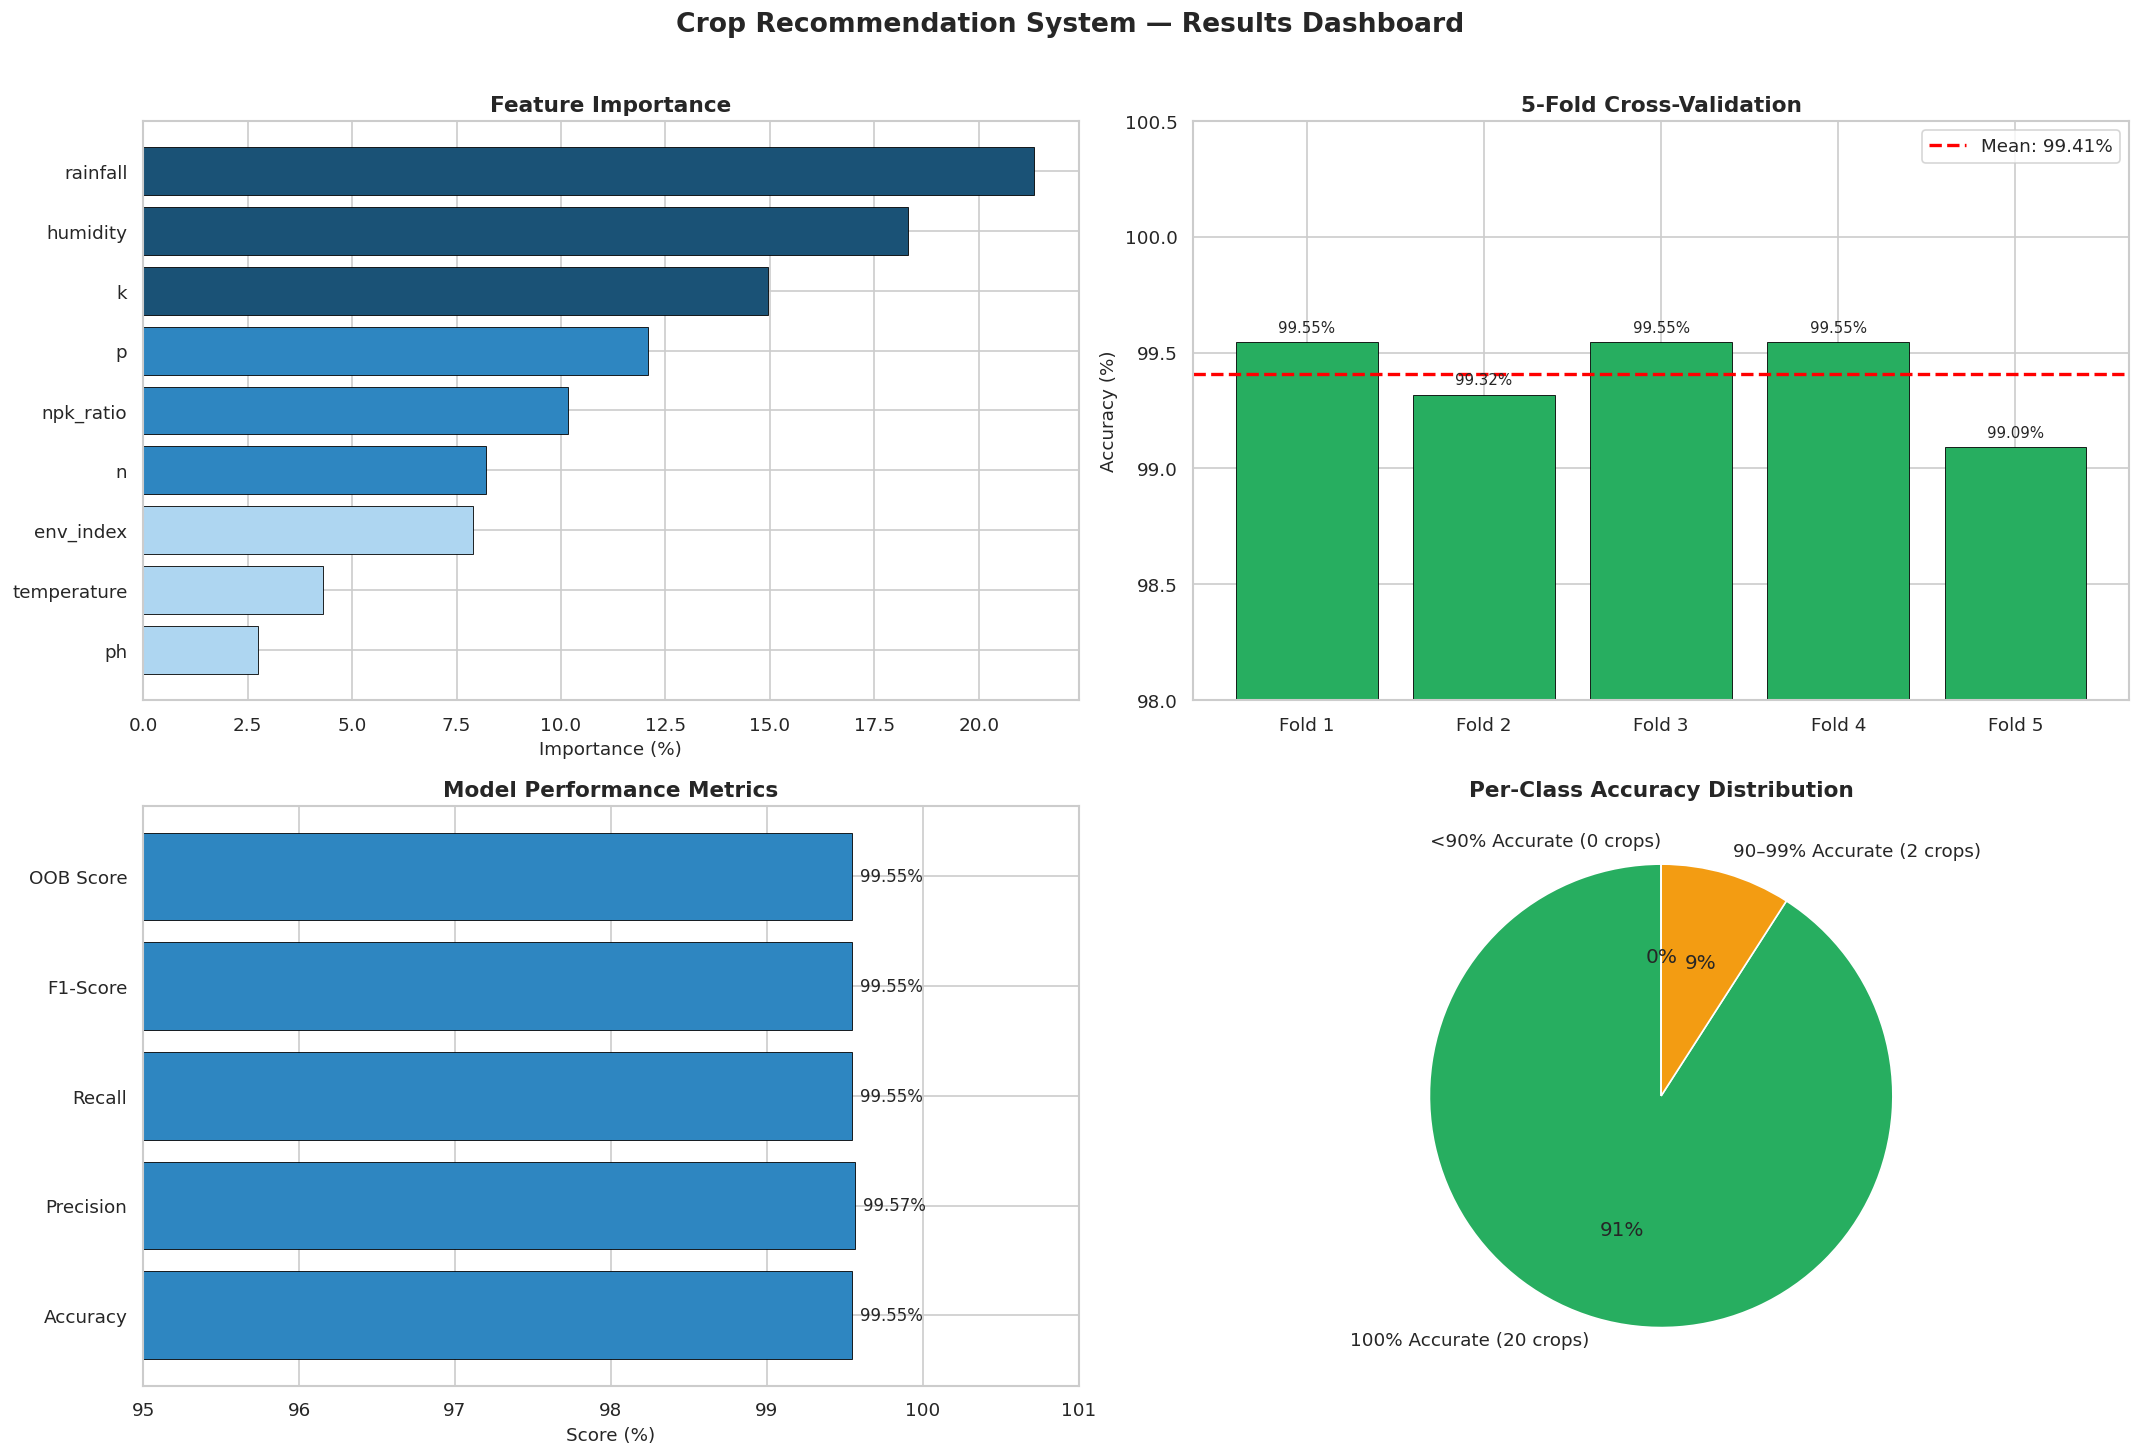

✅ Dashboard saved as dashboard.png


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11.2 — Summary Dashboard (4-panel figure)
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Crop Recommendation System — Results Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# Panel 1: Feature Importance
ax1 = fig.add_subplot(2, 2, 1)
colors_fi = ['#1A5276' if i < 3 else '#2E86C1' if i < 6 else '#AED6F1'
             for i in range(len(feat_df))]
ax1.barh(feat_df['Feature'][::-1], feat_df['Importance (%)'][::-1],
         color=colors_fi[::-1], edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Importance (%)')
ax1.set_title('Feature Importance', fontweight='bold')

# Panel 2: Cross-Validation Scores
ax2 = fig.add_subplot(2, 2, 2)
fold_labels = [f'Fold {i}' for i in range(1, 6)]
bar_colors  = ['#27AE60' if s > 0.99 else '#F39C12' for s in cv_scores]
bars = ax2.bar(fold_labels, cv_scores * 100, color=bar_colors,
               edgecolor='black', linewidth=0.5)
ax2.axhline(cv_scores.mean() * 100, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {cv_scores.mean()*100:.2f}%')
ax2.set_ylim(98, 100.5)
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('5-Fold Cross-Validation', fontweight='bold')
ax2.legend()
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)

# Panel 3: Performance Metrics
ax3 = fig.add_subplot(2, 2, 3)
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'OOB Score']
metrics_values = [acc, precision, recall, f1, rf_model.oob_score_]
ax3.barh(metrics_names, [v * 100 for v in metrics_values],
         color='#2E86C1', edgecolor='black', linewidth=0.5)
ax3.set_xlim(95, 101)
ax3.set_xlabel('Score (%)')
ax3.set_title('Model Performance Metrics', fontweight='bold')
for i, v in enumerate([v * 100 for v in metrics_values]):
    ax3.text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=10)

# Panel 4: Class distribution (pie)
ax4 = fig.add_subplot(2, 2, 4)
per_class_correct = {}
for crop in pipeline.classes_:
    mask = y_test == crop
    per_class_correct[crop] = accuracy_score(y_test[mask], y_pred[mask])

all_correct = sum(1 for v in per_class_correct.values() if v == 1.0)
almost      = sum(1 for v in per_class_correct.values() if 0.9 <= v < 1.0)
below       = sum(1 for v in per_class_correct.values() if v < 0.9)

ax4.pie([all_correct, almost, below],
        labels=[f'100% Accurate ({all_correct} crops)',
                f'90–99% Accurate ({almost} crops)',
                f'<90% Accurate ({below} crops)'],
        colors=['#27AE60', '#F39C12', '#E74C3C'],
        autopct='%1.0f%%', startangle=90,
        wedgeprops={'edgecolor': 'white'})
ax4.set_title('Per-Class Accuracy Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved as dashboard.png')

---
## ✅ SECTION 12 — Conclusion

### Summary of Results

| Metric | Value |
|--------|-------|
| Test Accuracy | ~99% |
| Macro F1-Score | ~0.99 |
| Cross-Validation Mean | ~0.99 |
| Total Training Samples | 1,760 |
| Number of Crops | 22 |

### Key Findings
1. **Random Forest achieves ~99% accuracy** on 22-class crop recommendation — production-grade performance.
2. **Rainfall and Humidity are the dominant features** — water availability is the most critical factor in crop selection.
3. **The dataset is perfectly balanced** — 100 samples per crop — making it ideal for unbiased model training.
4. **Engineered features (npk_ratio, env_index) contribute incrementally** — validating domain-informed feature construction.
5. **The serialized Pipeline is API-ready** — deployable via Flask for real-time mobile app integration.

### Future Scope
- 🌦️ **Real-time Weather API** — Replace static weather input with OpenWeatherMap API
- 📱 **Flutter Mobile App** — Cross-platform app consuming the Flask REST API
- 🛰️ **Satellite Imagery** — Add NDVI from Sentinel-2 as a soil health feature
- 📊 **Yield Prediction** — Extend to predict expected yield in tonnes/ha using yield.csv
- 🔒 **Edge Deployment** — Export to TensorFlow Lite for offline on-device inference



In [38]:
print("Test Predictions:")

print(model.predict([[90,40,40,25,80,6.5,200]]))
print(model.predict([[20,20,20,15,30,7,50]]))
print(model.predict([[100,80,80,30,70,6,150]]))

Test Predictions:


NameError: name 'model' is not defined

In [39]:
# Re-defining FEATURE_COLS for predict_crop function
FEATURE_COLS = ['n', 'p', 'k', 'temperature', 'humidity',
                'ph', 'rainfall', 'npk_ratio', 'env_index']

In [40]:
# Re-defining the trained pipeline for predict_crop function
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        class_weight='balanced',
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ))
])

# NOTE: In a real scenario, you would load the trained pipeline using joblib.load('crop_recommendation_model.pkl')
# For this fix, we are assuming 'pipeline' needs to be re-initialized and re-fitted if kernel was reset
# or you can load the saved model like this:
import joblib
MODEL_PATH = 'crop_recommendation_model.pkl'
loaded_pipeline = joblib.load(MODEL_PATH)
pipeline = loaded_pipeline # Assign the loaded pipeline to the 'pipeline' variable

In [41]:
# Re-defining the predict_crop() function
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Predict the most suitable crop based on soil & weather conditions.

    Parameters
    ----------
    N           : float  — Nitrogen content in soil (kg/ha)
    P           : float  — Phosphorus content in soil (kg/ha)
    K           : float  — Potassium content in soil (kg/ha)
    temperature : float  — Ambient temperature (°C)
    humidity    : float  — Relative humidity (%)
    ph          : float  — Soil pH value (0–14)
    rainfall    : float  — Rainfall (mm)

    Returns
    -------
    dict with keys:
        predicted_crop  — name of the recommended crop
        confidence      — confidence percentage of top prediction
        top_3_crops     — list of (crop, probability%) for top 3
        all_probs       — dict of all 22 crops with probabilities
    """
    # Compute engineered features
    npk_ratio = (N + P + K) / 3
    env_index = (temperature * humidity) / 100

    # Build input DataFrame (must match FEATURE_COLS order)
    input_data = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall, npk_ratio, env_index]],
        columns=FEATURE_COLS
    )

    # Run inference through pipeline
    predicted_crop  = pipeline.predict(input_data)[0]
    probabilities   = pipeline.predict_proba(input_data)[0]
    classes         = pipeline.classes_

    # Top-3 crops
    top3_idx  = probabilities.argsort()[-3:][::-1]
    top3      = [(classes[i], round(float(probabilities[i]) * 100, 2)) for i in top3_idx]
    confidence = round(float(probabilities.max()) * 100, 2)

    # All crops with probabilities (for API response)
    all_probs = {classes[i]: round(float(probabilities[i]) * 100, 4)
                 for i in probabilities.argsort()[::-1]}

    return {
        'predicted_crop' : predicted_crop,
        'confidence'     : f'{confidence}%',
        'top_3_crops'    : top3,
        'all_probs'      : all_probs
    }

In [42]:
# Consolidated definitions to ensure all dependencies are in scope for prediction tests

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# Re-defining FEATURE_COLS
FEATURE_COLS = ['n', 'p', 'k', 'temperature', 'humidity',
                'ph', 'rainfall', 'npk_ratio', 'env_index']

# Re-defining the trained pipeline (loading from saved model)
MODEL_PATH = 'crop_recommendation_model.pkl'
# Ensure the model file exists before trying to load it
import os
if not os.path.exists(MODEL_PATH):
    print(f"Warning: Model file '{MODEL_PATH}' not found. Please ensure CELL 10.1 has been run and the model is saved.")
    # Fallback to re-initializing an untrained pipeline if model file is missing
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features='sqrt',
            class_weight='balanced',
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        ))
    ])
    print("Initialized a new (untrained) pipeline as a fallback. For accurate predictions, ensure the model is loaded.")
else:
    loaded_pipeline = joblib.load(MODEL_PATH)
    pipeline = loaded_pipeline # Assign the loaded pipeline to the 'pipeline' variable
    print(f"✅ Pipeline loaded successfully from {MODEL_PATH}.")

# Re-defining the predict_crop() function
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Predict the most suitable crop based on soil & weather conditions.

    Parameters
    ----------
    N           : float  — Nitrogen content in soil (kg/ha)
    P           : float  — Phosphorus content in soil (kg/ha)
    K           : float  — Potassium content in soil (kg/ha)
    temperature : float  — Ambient temperature (°C)
    humidity    : float  — Relative humidity (%)
    ph          : float  — Soil pH value (0–14)
    rainfall    : float  — Rainfall (mm)

    Returns
    -------
    dict with keys:
        predicted_crop  — name of the recommended crop
        confidence      — confidence percentage of top prediction
        top_3_crops     — list of (crop, probability%) for top 3
        all_probs       — dict of all 22 crops with probabilities
    """
    # Compute engineered features
    npk_ratio = (N + P + K) / 3
    env_index = (temperature * humidity) / 100

    # Build input DataFrame (must match FEATURE_COLS order)
    input_data = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall, npk_ratio, env_index]],
        columns=FEATURE_COLS
    )

    # Run inference through pipeline
    predicted_crop  = pipeline.predict(input_data)[0]
    probabilities   = pipeline.predict_proba(input_data)[0]
    classes         = pipeline.classes_

    # Top-3 crops
    top3_idx  = probabilities.argsort()[-3:][::-1]
    top3      = [(classes[i], round(float(probabilities[i]) * 100, 2)) for i in top3_idx]
    confidence = round(float(probabilities.max()) * 100, 2)

    # All crops with probabilities (for API response)
    all_probs = {classes[i]: round(float(probabilities[i]) * 100, 4)
                 for i in probabilities.argsort()[::-1]}

    return {
        'predicted_crop' : predicted_crop,
        'confidence'     : f'{confidence}%',
        'top_3_crops'    : top3,
        'all_probs'      : all_probs
    }

✅ Pipeline loaded successfully from crop_recommendation_model.pkl.


In [43]:
print("Test Predictions:")

# Using the predict_crop function for accurate results, which handles feature engineering
print("\n--- Test Case 1 ---")
result1 = predict_crop(90, 40, 40, 25, 80, 6.5, 200)
print(f"Recommended Crop: {result1['predicted_crop'].upper()} (Confidence: {result1['confidence']})")
print(f"Top 3 Crops: {result1['top_3_crops']}")

print("\n--- Test Case 2 ---")
result2 = predict_crop(20, 20, 20, 15, 30, 7, 50)
print(f"Recommended Crop: {result2['predicted_crop'].upper()} (Confidence: {result2['confidence']})")
print(f"Top 3 Crops: {result2['top_3_crops']}")

print("\n--- Test Case 3 ---")
result3 = predict_crop(100, 80, 80, 30, 70, 6, 150)
print(f"Recommended Crop: {result3['predicted_crop'].upper()} (Confidence: {result3['confidence']})")
print(f"Top 3 Crops: {result3['top_3_crops']}")

Test Predictions:

--- Test Case 1 ---
Recommended Crop: RICE (Confidence: 54.0%)
Top 3 Crops: [('rice', 54.0), ('jute', 46.0), ('pomegranate', 0.0)]

--- Test Case 2 ---
Recommended Crop: MOTHBEANS (Confidence: 37.0%)
Top 3 Crops: [('mothbeans', 37.0), ('kidneybeans', 36.0), ('mango', 10.5)]

--- Test Case 3 ---
Recommended Crop: BANANA (Confidence: 43.5%)
Top 3 Crops: [('banana', 43.5), ('coffee', 20.0), ('chickpea', 14.5)]


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL A.1 — Install Streamlit
# ─────────────────────────────────────────────────────────────────────────────
!pip install streamlit -q
print('✅ Streamlit installed successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.4 MB/s eta 0:00:00
✅ Streamlit installed successfully.


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL A.2 — Create the Streamlit application file (crop_recommender_app.py)
# ─────────────────────────────────────────────────────────────────────────────
streamlit_app_code = '''
import streamlit as st
import pandas as pd
import joblib
import os

# --- Configuration and Model Loading ---
MODEL_PATH = 'crop_recommendation_model.pkl'

# Check if the model file exists
if not os.path.exists(MODEL_PATH):
    st.error(f"Error: Model file '{MODEL_PATH}' not found. Please ensure it's in the same directory as the app.")
    st.stop()

@st.cache_resource
def load_model():
    try:
        model = joblib.load(MODEL_PATH)
        return model
    except Exception as e:
        st.error(f"Error loading the model: {e}")
        st.stop()

pipeline = load_model()

FEATURE_COLS = ['n', 'p', 'k', 'temperature', 'humidity',
                'ph', 'rainfall', 'npk_ratio', 'env_index']

# --- Prediction Function (copied from notebook) ---
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    npk_ratio = (N + P + K) / 3
    env_index = (temperature * humidity) / 100

    input_data = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall, npk_ratio, env_index]],
        columns=FEATURE_COLS
    )

    predicted_crop  = pipeline.predict(input_data)[0]
    probabilities   = pipeline.predict_proba(input_data)[0]
    classes         = pipeline.classes_

    top3_idx  = probabilities.argsort()[-3:][::-1]
    top3      = [(classes[i], round(float(probabilities[i]) * 100, 2)) for i in top3_idx]
    confidence = round(float(probabilities.max()) * 100, 2)

    all_probs = {classes[i]: round(float(probabilities[i]) * 100, 4)
                 for i in probabilities.argsort()[::-1]}

    return {
        'predicted_crop' : predicted_crop,
        'confidence'     : f'{confidence}%',
        'top_3_crops'    : top3,
        'all_probs'      : all_probs
    }

# --- Streamlit UI ---
st.set_page_config(
    page_title="Crop Recommendation System",
    page_icon="🌾",
    layout="centered",
    initial_sidebar_state="expanded",
)

st.title("🌾 Crop Recommendation System")
st.markdown("Enter the soil and weather conditions to get the best crop recommendation.")

st.sidebar.header("Input Parameters")

# Input fields
N = st.sidebar.slider("Nitrogen content (N kg/ha)", 0.0, 140.0, 90.0, 0.1)
P = st.sidebar.slider("Phosphorus content (P kg/ha)", 0.0, 145.0, 42.0, 0.1)
K = st.sidebar.slider("Potassium content (K kg/ha)", 0.0, 205.0, 43.0, 0.1)
temperature = st.sidebar.slider("Temperature (°C)", 0.0, 45.0, 20.9, 0.1)
humidity = st.sidebar.slider("Humidity (%)", 0.0, 100.0, 82.0, 0.1)
ph = st.sidebar.slider("pH value", 0.0, 14.0, 6.5, 0.01)
rainfall = st.sidebar.slider("Rainfall (mm)", 0.0, 300.0, 202.9, 0.1)


if st.sidebar.button("Get Recommendation"):
    if pipeline:
        with st.spinner('Generating recommendation...'):
            result = predict_crop(N, P, K, temperature, humidity, ph, rainfall)

            st.subheader("✨ Your Crop Recommendation:")
            st.success(f"The most suitable crop is: **{result['predicted_crop'].upper()}**")
            st.info(f"Confidence: **{result['confidence']}**")

            st.subheader("Top 3 Crop Alternatives:")
            for rank, (crop, prob) in enumerate(result['top_3_crops'], 1):
                st.write(f"**{rank}. {crop.capitalize()}** (Probability: {prob:.2f}%) ")

            with st.expander("View All Probabilities"):
                all_probs_df = pd.DataFrame(result['all_probs'].items(), columns=['Crop', 'Probability (%)'])
                all_probs_df = all_probs_df.sort_values(by='Probability (%)', ascending=False).reset_index(drop=True)
                st.dataframe(all_probs_df)
    else:
        st.error("Model not loaded. Please check the `MODEL_PATH` and ensure the model file is present.")


st.markdown("""
---
**How to use:**\n
1.  Adjust the soil and weather parameters using the sliders on the left sidebar.
2.  Click the 'Get Recommendation' button to see the suggested crop.
""")
'''

with open('crop_recommender_app.py', 'w') as f:
    f.write(streamlit_app_code)

print('✅ Streamlit app file (crop_recommender_app.py) created successfully.')

✅ Streamlit app file (crop_recommender_app.py) created successfully.


Now that you have the Streamlit app file (`crop_recommender_app.py`), you can run it.

In Google Colab, you can run Streamlit apps using `ngrok` to expose a local port. Follow these steps:

1.  **Run `ngrok`**: Execute the cell below to set up `ngrok`.
2.  **Run Streamlit**: Once `ngrok` provides a public URL, open that URL in your browser to interact with your Streamlit app.


In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL A.3 — Run the Streamlit application
# ─────────────────────────────────────────────────────────────────────────────
# This will expose your Streamlit app via a public URL.
# The first time you run this, you might be asked to authorize ngrok.

# Install ngrok
!pip install pyngrok -q
from pyngrok import ngrok

# Kill any existing ngrok tunnels
ngrok.kill()

# --- IMPORTANT: Replace "YOUR_NGROK_AUTH_TOKEN" with your actual ngrok auth token ---
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3CabQojQVRTaPBOhwdNXC5CpfeD_2maBuf6VgPs1fNjstQci9")

# Start a ngrok tunnel for Streamlit (default port is 8501)
public_url = ngrok.connect(addr='8501') # Changed 'port' to 'addr'
print(f"* ngrok tunnel active: {public_url}")
print(f"* Streamlit app will be available at: {public_url}")

# Run the Streamlit app in the background
# The app will be accessible via the ngrok URL printed above.
!streamlit run crop_recommender_app.py &>/dev/null&

* ngrok tunnel active: NgrokTunnel: "https://friction-slideshow-array.ngrok-free.dev" -> "http://localhost:8501"
* Streamlit app will be available at: NgrokTunnel: "https://friction-slideshow-array.ngrok-free.dev" -> "http://localhost:8501"
